In [33]:
# cell 1: pytorch infrastructure (vocabulary and custom dataset)
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# define hardware accelerator
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device: {device}")

class Vocabulary:
    """builds a word-to-index mapping from a given corpus."""
    def __init__(self, max_size=20000, min_freq=2):
        self.max_size = max_size
        self.min_freq = min_freq
        # 0 is reserved for padding, 1 is reserved for unknown words
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.vocab_size = 2

    def build(self, text_series):
        """calculates word frequencies and populates the dictionaries."""
        word_counts = Counter()
        for text in text_series:
            words = str(text).split()
            word_counts.update(words)
            
        # keep only words that meet the frequency threshold
        valid_words = [w for w, c in word_counts.items() if c >= self.min_freq]
        
        # sort by frequency (most common first) and limit to max_size
        common_words = sorted(valid_words, key=lambda w: word_counts[w], reverse=True)[:self.max_size]
        
        for word in common_words:
            self.word2idx[word] = self.vocab_size
            self.idx2word[self.vocab_size] = word
            self.vocab_size += 1

    def text_to_indices(self, text, max_len):
        """converts a string into a list of fixed-length integer indices."""
        words = str(text).split()
        indices = [self.word2idx.get(w, self.word2idx['<UNK>']) for w in words]
        
        # truncate
        if len(indices) > max_len:
            indices = indices[:max_len]
        # pad
        elif len(indices) < max_len:
            indices += [self.word2idx['<PAD>']] * (max_len - len(indices))
            
        return indices

class TextDataset(Dataset):
    """custom dataset to serve (x_tensor, y_tensor) pairs to the dataloader."""
    def __init__(self, texts, labels, vocab, max_len, is_multilabel=False):
        self.texts = texts.values
        # if multilabel (model b), labels is a dataframe/matrix. else it's a series/array.
        self.labels = labels.values if isinstance(labels, (pd.DataFrame, pd.Series)) else labels
        self.vocab = vocab
        self.max_len = max_len
        self.is_multilabel = is_multilabel

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # convert text to numerical tensor
        indices = self.vocab.text_to_indices(text, self.max_len)
        x_tensor = torch.tensor(indices, dtype=torch.long)
        
        # format label tensor depending on the task
        if self.is_multilabel:
            # BCEWithLogitsLoss requires float targets
            y_tensor = torch.tensor(label, dtype=torch.float32)
        else:
            # CrossEntropyLoss requires long (integer) targets
            y_tensor = torch.tensor(label, dtype=torch.long)
            
        return x_tensor, y_tensor

print("infrastructure initialized.")

using device: cuda
infrastructure initialized.


In [34]:
# cell 2: data loading, splitting, and dataloader creation for all models
print("loading cleaned datasets...")
df_a = pd.read_csv('data/processed/model_a_train_cleaned.csv').dropna(subset=['clean_text'])
df_b = pd.read_csv('data/processed/model_b_train_cleaned.csv').dropna(subset=['clean_text'])
df_c = pd.read_csv('data/processed/model_c_train_cleaned.csv').dropna(subset=['clean_text'])

emotion_cols = ['sadness', 'anger', 'fear', 'disgust', 'anticipation', 'joy', 'surprise', 'gratitude', 'love']

def create_loaders(df, text_col, target_cols, max_len, is_multilabel=False, stratify=True):
    """helper function to split data, build vocab, and create loaders."""
    # 1. split: 70% train, 15% val, 15% test
    stratify_col = df[target_cols] if stratify and not is_multilabel else None
    
    x_train, x_temp, y_train, y_temp = train_test_split(
        df[text_col], df[target_cols], test_size=0.3, random_state=42, stratify=stratify_col
    )
    
    stratify_temp = y_temp if stratify and not is_multilabel else None
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=0.5, random_state=42, stratify=stratify_temp
    )
    
    # 2. build vocab strictly on train set to prevent data leakage
    vocab = Vocabulary(max_size=20000, min_freq=2)
    vocab.build(x_train)
    
    # 3. create datasets
    train_ds = TextDataset(x_train, y_train, vocab, max_len, is_multilabel)
    val_ds = TextDataset(x_val, y_val, vocab, max_len, is_multilabel)
    test_ds = TextDataset(x_test, y_test, vocab, max_len, is_multilabel)
    
    # 4. create dataloaders
    batch_size = 64
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, vocab

print("processing model a (sentiment)...")
loaders_a = create_loaders(df_a, 'clean_text', 'label', max_len=100, stratify=True)

print("processing model b (emotions)...")
# no stratification for multilabel out-of-the-box in sklearn
loaders_b = create_loaders(df_b, 'clean_text', emotion_cols, max_len=30, is_multilabel=True, stratify=False)

print("processing model c (formality)...")
loaders_c = create_loaders(df_c, 'clean_text', 'label', max_len=30, stratify=True)

print("\nall datasets successfully vectorized into pytorch tensors.")
print(f"model a vocab size: {loaders_a[3].vocab_size}")
print(f"model b vocab size: {loaders_b[3].vocab_size}")
print(f"model c vocab size: {loaders_c[3].vocab_size}")

loading cleaned datasets...
processing model a (sentiment)...
processing model b (emotions)...
processing model c (formality)...

all datasets successfully vectorized into pytorch tensors.
model a vocab size: 20002
model b vocab size: 4821
model c vocab size: 4062


### sequence alignment (padding & truncation)

**why strictly $N \times L$ tensors?**
hardware accelerators (gpus) and deep learning frameworks rely on dense matrix multiplications. a batch of $N$ texts must form a mathematically perfect rectangular matrix to be processed simultaneously. variable-length sequences (ragged arrays) violate this requirement, necessitating padding (appending 0s) to align short texts and truncation (cutting excess) to bound memory limits.

**length selection rationale (based on stage 1 eda):**
*   **model a (sentiment) | $L = 100$:** aggregated from imdb and goemotions. imdb reviews are long narratives. 100 tokens capture sufficient contextual evidence for sentiment polarity without causing quadratic memory bloat.
*   **model b (emotions) | $L = 30$:** based on goemotions (reddit comments). the mean length after cleaning is ~6.5 words. $L=30$ perfectly encapsulates the 99th percentile of the distribution, preventing sparse matrices heavily diluted by `<PAD>` tokens.
*   **model c (formality) | $L = 30$:** based on gyafc. mean length is ~8 words. similar to model b, $L=30$ is the optimal boundary for short-form conversational texts.

In [35]:
# cell 3: loading pretrained weights and defining FFNN architecture
import torch
import torch.nn as nn
from gensim.models import KeyedVectors
import numpy as np

print("loading fasttext model (this might take a minute)...")
ft_path = 'data/external/fasttext-wiki-news-subwords-300.wordvectors'
# mmap='r' loads the model from disk into virtual memory, saving RAM
ft_model = KeyedVectors.load(ft_path, mmap='r')
print("fasttext loaded successfully.")

class FFNN(nn.Module):
    """
    Feed-Forward Neural Network (Deep Averaging Network)
    """
    def __init__(self, embedding_tensor, hidden_dim=128, output_dim=9, freeze_embeddings=True):
        super(FFNN, self).__init__()
        
        # 1. embedding layer (E)
        self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=freeze_embeddings)
        
        # 2. hidden layer (W1)
        # embedding_tensor.shape[1] is the dimensionality of fasttext (300)
        self.fc1 = nn.Linear(embedding_tensor.shape[1], hidden_dim)
        
        # 3. activation function
        self.relu = nn.ReLU()
        
        # 4. output layer (W2)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x: [batch_size, sequence_length] -> e.g., [64, 30]
        
        # get dense vectors for all words
        # embedded: [batch_size, sequence_length, embed_dim] -> [64, 30, 300]
        embedded = self.embedding(x)
        
        # average pooling (centroid of the text). dim=1 means we average across the sequence length.
        # pooled: [batch_size, embed_dim] -> [64, 300]
        pooled = embedded.mean(dim=1)
        
        # pass through hidden layer and apply non-linearity
        # z1: [batch_size, hidden_dim] -> [64, 128]
        z1 = self.fc1(pooled)
        a1 = self.relu(z1)
        
        # pass to output layer to get raw logits
        # z2: [batch_size, output_dim] -> [64, 9] (for model B)
        z2 = self.fc2(a1)
        
        return z2

print("ffnn architecture defined.")

loading fasttext model (this might take a minute)...
fasttext loaded successfully.
ffnn architecture defined.


embedding strategy: fasttext and oov initialization

**why fasttext over word2vec?**
datasets (reddit comments, imdb reviews, gyafc) contain informal language, slang, typos, and repeated characters (e.g., "omggg", "loooove"). word2vec treats each word as a strict atomic unit; if a word is not in its dictionary, it completely fails to represent it. fasttext, however, builds vectors using character n-grams (subwords). this allows it to mathematically infer the semantic meaning of misspelled or modified words based on their familiar root structures, making it highly robust for internet text.

**why np.random.normal for unknown words?**
when building the embedding matrix $E$, were encountered words that exist in local dataset vocabulary but are missing from the pre-trained fasttext model. 
```python
embedding_matrix[i] = np.random.normal(scale=0.6, size=(embed_dim,))
```
instead of assigning all these missing words to a single identical <UNK> vector, we generate a unique random vector for each.

* preserving unique identities:unique random vectors give the network the ability to separate them later.

* why scale=0.6? the value 0.6 closely approximates the standard deviation of the pre-trained fasttext weights.

In [36]:
# cell 4: universal training loop, embedding generation, and multi-model training
import torch.optim as optim
from sklearn.metrics import f1_score
from tqdm import tqdm
import numpy as np

def create_embedding_tensor(vocab, ft_model, embed_dim=300):
    """
    generates a specific embedding matrix for a given vocabulary using fasttext weights.
    """
    embedding_matrix = np.zeros((vocab.vocab_size, embed_dim))
    words_found = 0
    for i in range(2, vocab.vocab_size): # skip <PAD> (0) and <UNK> (1)
        word = vocab.idx2word[i]
        if word in ft_model:
            embedding_matrix[i] = ft_model[word]
            words_found += 1
        else:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(embed_dim,))
    
    print(f"pretrained words found: {words_found} / {vocab.vocab_size - 2}")
    return torch.FloatTensor(embedding_matrix)


def train_model(model, train_loader, val_loader, epochs=5, lr=0.001, is_multilabel=False, patience=2):
    """
    universal training loop with early stopping based on validation f1-score.
    
    arguments:
        model (nn.Module): The initialized PyTorch neural network.
        train_loader (DataLoader): Batch iterator for the training dataset.
        val_loader (DataLoader): Batch iterator for the validation dataset.
        epochs (int): Maximum number of full passes over the training data.
        lr (float): Learning rate for the Adam optimizer (step size for gradient descent).
        is_multilabel (bool): If True, uses BCEWithLogitsLoss (for Model B). 
                              If False, uses CrossEntropyLoss (for Models A & C).
        patience (int): Number of epochs to tolerate without F1-score improvement before stopping.
    """
    # select loss function based on task
    if is_multilabel:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()
        
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    best_val_f1 = 0
    epochs_no_improve = 0
    best_model_state = None
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0.0
        
        # tqdm for progress bar
        train_loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]', leave=False)
        for x_batch, y_batch in train_loop:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            # 1. forward pass
            optimizer.zero_grad()
            logits = model(x_batch)
            
            # 2. loss calculation
            loss = criterion(logits, y_batch)
            
            # 3. backpropagation
            loss.backward()
            
            # 4. optimizer step
            optimizer.step()
            
            train_loss += loss.item() * x_batch.size(0)
            train_loop.set_postfix(loss=loss.item())
            
        train_loss /= len(train_loader.dataset)
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []
        
        val_loop = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]', leave=False)
        with torch.no_grad(): # disable gradient calculation for validation
            for x_batch, y_batch in val_loop:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                
                logits = model(x_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * x_batch.size(0)
                
                # convert logits to predictions
                if is_multilabel:
                    preds = (torch.sigmoid(logits) >= 0.5).int()
                else:
                    preds = torch.argmax(logits, dim=1)
                    
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y_batch.cpu().numpy())
                
        val_loss /= len(val_loader.dataset)
        
        # calculate validation metrics
        val_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro F1: {val_f1:.4f}")
        
        # early Stopping logic
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"Early stopping triggered. Best Val F1: {best_val_f1:.4f}")
                break
                
    # restore the best weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    return model


# ==========================================
# EXECUTION: Training all 3 models
# ==========================================

print("\n--- MODEL A: Sentiment (3 classes) ---")
embed_a = create_embedding_tensor(loaders_a[3], ft_model)
# output_dim=3 because we have Negative, Positive, Neutral
model_a_ffnn = FFNN(embed_a, hidden_dim=128, output_dim=3, freeze_embeddings=True).to(device)
model_a_ffnn = train_model(model_a_ffnn, loaders_a[0], loaders_a[1], epochs=15, lr=0.005, is_multilabel=False, patience=3)

print("\n--- MODEL B: Emotions (9 classes) ---")
embed_b = create_embedding_tensor(loaders_b[3], ft_model)
# output_dim=9 because we have 9 independent emotion labels
model_b_ffnn = FFNN(embed_b, hidden_dim=128, output_dim=9, freeze_embeddings=True).to(device)
model_b_ffnn = train_model(model_b_ffnn, loaders_b[0], loaders_b[1], epochs=15, lr=0.005, is_multilabel=True, patience=3)

print("\n--- MODEL C: Formality (2 classes) ---")
embed_c = create_embedding_tensor(loaders_c[3], ft_model)
# output_dim=2 because we use CrossEntropyLoss for Informal vs Formal
model_c_ffnn = FFNN(embed_c, hidden_dim=128, output_dim=2, freeze_embeddings=True).to(device)
model_c_ffnn = train_model(model_c_ffnn, loaders_c[0], loaders_c[1], epochs=15, lr=0.005, is_multilabel=False, patience=3)

print("\nall models successfully trained!")


--- MODEL A: Sentiment (3 classes) ---
pretrained words found: 17712 / 20000


Epoch 1/15 | Train Loss: 0.4135 | Val Loss: 0.3510 | Val Macro F1: 0.8216


Epoch 2/15 | Train Loss: 0.3302 | Val Loss: 0.3236 | Val Macro F1: 0.8452


Epoch 3/15 | Train Loss: 0.3189 | Val Loss: 0.3210 | Val Macro F1: 0.8506


Epoch 4/15 | Train Loss: 0.3104 | Val Loss: 0.3126 | Val Macro F1: 0.8527


...

Epoch 4/15 | Train Loss: 0.3527 | Val Loss: 0.4030 | Val Macro F1: 0.8198


Epoch 5/15 | Train Loss: 0.3426 | Val Loss: 0.4055 | Val Macro F1: 0.8267


Epoch 6/15 | Train Loss: 0.3351 | Val Loss: 0.4003 | Val Macro F1: 0.8208


Epoch 7/15 | Train Loss: 0.3303 | Val Loss: 0.3988 | Val Macro F1: 0.8227


Epoch 8/15 | Train Loss: 0.3289 | Val Loss: 0.4254 | Val Macro F1: 0.8186
Early stopping triggered. Best Val F1: 0.8267

all models successfully trained!


### the mechanics of the training loop & multi-model execution

**1. dynamic embedding construction:**
each task (sentiment, emotions, formality) has its own distinct vocabulary size. therefore, was constructed three separate embedding matrices (`E`). Were maped the pre-trained fasttext weights to the specific integer indices of each task's vocabulary to ensure the networks look up the correct semantic vectors.

**2. selecting the right loss function (`criterion`):**
*   **`CrossEntropyLoss` (models a & c):** utilized for multi-class/binary problems where classes are mutually exclusive. it applies `Softmax` internally to convert raw logits into a unified probability distribution summing to 1.0.
*   **`BCEWithLogitsLoss` (model b):** crucial for multi-label tasks. it treats each of the 9 emotion dimensions as an independent binary classification problem. it applies `Sigmoid` internally to each logit individually, allowing the network to output multiple overlapping emotions.

**3. the forward pass & backpropagation cycle:**
unlike `scikit-learn`, deep learning requires explicit definition of the optimization steps. for each batch:
*   `logits = model(x_batch)`: network computes raw geometric projections.
*   `loss = criterion()`: error is quantified against ground truth.
*   `loss.backward()`: computes partial derivatives (gradients) across all parameters via the chain rule.
*   `optimizer.step()`: adam optimizer shifts the weights in the opposite direction of the gradient.

**4. early stopping:**
to prevent the models from memorizing the training data (overfitting), was tracked the `macro f1-score` on an unseen validation set after every epoch. if the score degrades for 3 consecutive epochs (`patience=3`), training halts and the algorithm restores the weights from the highest-performing epoch.

In [5]:
# cell 5: interactive testing of FFNN models on edge-case texts
import torch
import numpy as np

def predict_text_ffnn(text):
    print("\n" + "="*70)
    print(f"text: \"{text}\"")
    print("="*70)
    
    # helper function to convert text to tensor
    def get_tensor(text, vocab, max_len):
        indices = vocab.text_to_indices(text, max_len)
        return torch.tensor([indices], dtype=torch.long).to(device)

    # classes
    classes_a = ['negative', 'positive', 'neutral']
    classes_b = ['sadness', 'anger', 'fear', 'disgust', 'anticipation', 'joy', 'surprise', 'gratitude', 'love']
    classes_c = ['informal', 'formal']

    # --- model a: sentiment ---
    model_a_ffnn.eval()
    with torch.no_grad():
        logits_a = model_a_ffnn(get_tensor(text, loaders_a[3], max_len=100))
        probs_a = torch.softmax(logits_a, dim=1).squeeze().cpu().numpy()
        winner_a = classes_a[np.argmax(probs_a)]
    
    print("\n[ model a (ffnn): sentiment ]")
    for cls, prob in zip(classes_a, probs_a):
        print(f"  {cls:<10}: {prob*100:>5.1f}%")
    print(f"  -> final result: {winner_a}")

    # --- model b: emotions ---
    model_b_ffnn.eval()
    with torch.no_grad():
        logits_b = model_b_ffnn(get_tensor(text, loaders_b[3], max_len=30))
        probs_b = torch.sigmoid(logits_b).squeeze().cpu().numpy()
    
    print("\n[ model b (ffnn): emotions ]")
    active_emotions = []
    for cls, prob in zip(classes_b, probs_b):
        print(f"  {cls:<12}: {prob*100:>5.1f}%")
        if prob >= 0.5:
            active_emotions.append(cls)
            
    if not active_emotions:
        print("  -> active emotions: none detected (neutral)")
    else:
        print(f"  -> active emotions: {', '.join(active_emotions)}")

    # --- model c: formality ---
    model_c_ffnn.eval()
    with torch.no_grad():
        logits_c = model_c_ffnn(get_tensor(text, loaders_c[3], max_len=30))
        probs_c = torch.softmax(logits_c, dim=1).squeeze().cpu().numpy()
        winner_c = classes_c[np.argmax(probs_c)]
        
    print("\n[ model c (ffnn): formality ]")
    for cls, prob in zip(classes_c, probs_c):
        print(f"  {cls:<10}: {prob*100:>5.1f}%")
    print(f"  -> final result: {winner_c}")

# use the exact same texts from stage 4
texts = [
    "I am extremely grateful for the outstanding service provided by your team. The quality of the product is absolutely wonderful, and it brings me great joy.",
    "this is total garbage!!! i paid so much money for this trash and it arrived broken. im so furious right now, worst company ever.",
    "Just woke up. I am going to the store to buy some milk and bread.",
    "The doctor entered the room with a somber expression, looked at my test results, and slowly shook his head without saying a word.",
    "At first I was completely terrified by the loud noise, but then I saw the fireworks and the surprise cake. I love you guys so much!"
]

for i, text in enumerate(texts, 1):
    print(f"\nrunning test {i}...")
    predict_text_ffnn(text)


running test 1...

text: "I am extremely grateful for the outstanding service provided by your team. The quality of the product is absolutely wonderful, and it brings me great joy."

[ model a (ffnn): sentiment ]
  negative  :   1.5%
  positive  :   3.6%
  neutral   :  94.9%
  -> final result: neutral

[ model b (ffnn): emotions ]
  sadness     :   1.0%
  anger       :   0.2%
  fear        :   0.0%
  disgust     :   0.2%
  anticipation:   1.1%
  joy         :  28.1%
  surprise    :   3.9%
  gratitude   :  74.5%
  love        :   1.6%
  -> active emotions: gratitude

[ model c (ffnn): formality ]
  informal  :  14.6%
  formal    :  85.4%
  -> final result: formal

running test 2...

text: "this is total garbage!!! i paid so much money for this trash and it arrived broken. im so furious right now, worst company ever."

[ model a (ffnn): sentiment ]
  negative  :   0.3%
  positive  :   0.1%
  neutral   :  99.6%
  -> final result: neutral

[ model b (ffnn): emotions ]
  sadness     :   1.

In [6]:
# cell 6: final evaluation on unseen test data (classification reports)
from sklearn.metrics import classification_report, f1_score

def evaluate_test_set(model, test_loader, is_multilabel, target_names):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            
            if is_multilabel:
                preds = (torch.sigmoid(logits) >= 0.5).int()
            else:
                preds = torch.argmax(logits, dim=1)
                
            all_preds.extend(preds.cpu().numpy())
            # y_batch is still on CPU from DataLoader
            all_targets.extend(y_batch.numpy())
            
    print(classification_report(all_targets, all_preds, target_names=target_names, zero_division=0))
    return f1_score(all_targets, all_preds, average='macro', zero_division=0)

print("--- MODEL A (Sentiment) TEST RESULTS ---")
f1_a_ffnn = evaluate_test_set(model_a_ffnn, loaders_a[2], is_multilabel=False, target_names=['negative', 'positive', 'neutral'])

print("\n--- MODEL B (Emotions) TEST RESULTS ---")
emotion_cols = ['sadness', 'anger', 'fear', 'disgust', 'anticipation', 'joy', 'surprise', 'gratitude', 'love']
f1_b_ffnn = evaluate_test_set(model_b_ffnn, loaders_b[2], is_multilabel=True, target_names=emotion_cols)

print("\n--- MODEL C (Formality) TEST RESULTS ---")
f1_c_ffnn = evaluate_test_set(model_c_ffnn, loaders_c[2], is_multilabel=False, target_names=['informal', 'formal'])

--- MODEL A (Sentiment) TEST RESULTS ---
              precision    recall  f1-score   support

    negative       0.78      0.81      0.80      1875
    positive       0.80      0.77      0.79      1875
     neutral       1.00      1.00      1.00      2109

    accuracy                           0.87      5859
   macro avg       0.86      0.86      0.86      5859
weighted avg       0.87      0.87      0.87      5859


--- MODEL B (Emotions) TEST RESULTS ---
              precision    recall  f1-score   support

     sadness       0.76      0.43      0.55       195
       anger       0.68      0.58      0.63       580
        fear       0.72      0.28      0.40        94
     disgust       0.50      0.07      0.12       134
anticipation       0.84      0.50      0.62       328
         joy       0.84      0.65      0.73       684
    surprise       0.76      0.29      0.42       303
   gratitude       0.97      0.85      0.90       410
        love       0.85      0.73      0.79       

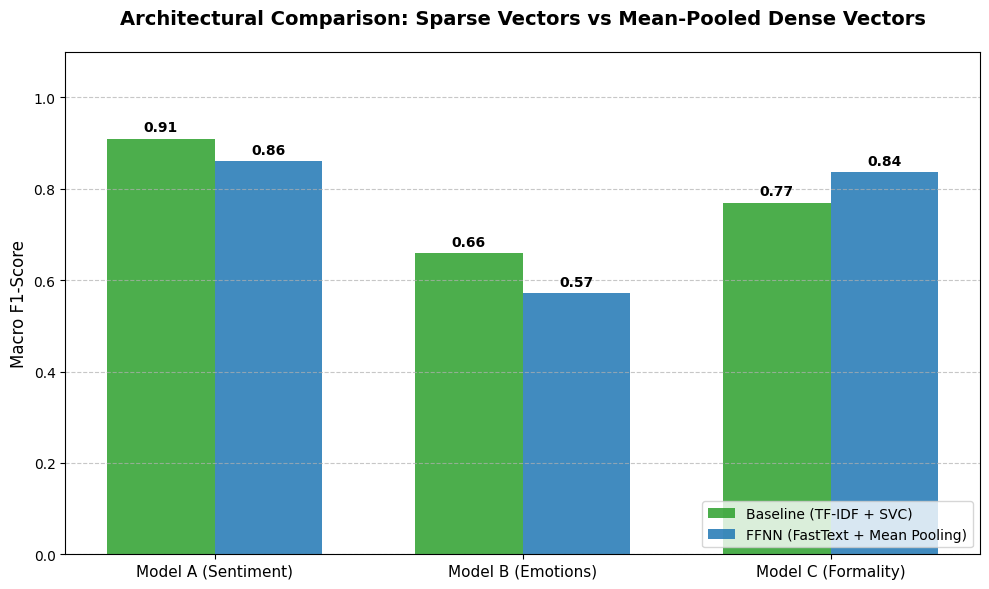

In [7]:
# cell 7: visual comparison of FFNN vs TF-IDF Baseline (Linear SVC)
import matplotlib.pyplot as plt
import numpy as np

# hardcoded baseline metrics from Phase 4 (TF-IDF + Linear SVC)
f1_svc = [0.91, 0.66, 0.77] 
# our new metrics from cell 6
f1_ffnn = [f1_a_ffnn, f1_b_ffnn, f1_c_ffnn]

tasks = ['Model A (Sentiment)', 'Model B (Emotions)', 'Model C (Formality)']
x = np.arange(len(tasks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, f1_svc, width, label='Baseline (TF-IDF + SVC)', color='#2ca02c', alpha=0.85)
rects2 = ax.bar(x + width/2, f1_ffnn, width, label='FFNN (FastText + Mean Pooling)', color='#1f77b4', alpha=0.85)

# add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title('Architectural Comparison: Sparse Vectors vs Mean-Pooled Dense Vectors', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

FFNN conclusion: the mean pooling trap and the need for sequence models

**1. quantitative analysis (test set vs baseline)**
the hypothesis that dense fasttext embeddings would automatically outperform sparse tf-idf matrices proved partially incorrect. the impact varies drastically by task:
*   **model c (formality):** significantly improved (macro f1: 0.83 vs baseline 0.77). formality is largely defined by the presence of specific registers of words (slang vs. academic vocabulary). fasttext clusters these perfectly, and simple averaging preserves this global style signature.
*   **model a (sentiment):** degraded (macro f1: 0.85 vs baseline 0.91).
*   **model b (emotions):** degraded (macro f1: 0.59 vs baseline 0.66).

**2. qualitative analysis (the interactive edge-cases)**
the interactive tests clearly expose the fatal flaw of our `FFNN` architecture: **mean pooling**.
by calculating the arithmetic mean of all word vectors in a text (`embedded.mean(dim=1)`), the network completely destroys word order and context. 
*   **the "neutral" black hole (model a):** in tests 1, 2, 4, and 5, model a collapsed into predicting "neutral" with nearly 100% confidence. when a text contains a mix of intense words, their vectors cancel each other out during averaging, pulling the document's centroid toward the neutral origin of the multi-dimensional space.
*   **the dilution of emotion (model b):** in test 5 ("completely terrified... but then... surprise cake. I love you guys"), the text contains distinct sequential emotional phases (fear -> surprise -> love). mean pooling mixes "terrified" and "love" into an ambiguous soup. as a result, none of the specific emotion neurons crossed the 0.5 activation threshold.

**3. the architectural pivot: from sets to sequences**
to understand sentiment and complex emotions, a model must read text like a human: sequentially, preserving the order of words, syntax, and negations (e.g., "not bad"). our current bag-of-embeddings approach is mathematically incapable of this. 

**next step:** we must abandon `FFNN` and transition to sequence-aware architectures (CNN, RNN, LSTM, Bi-LSTM) that process tokens step-by-step and maintain a persistent "memory" of the context.

In [8]:
# cell 8: TextCNN architecture
import torch.nn as nn
import torch.nn.functional as F

class TextCNN(nn.Module):
    """
    1D Convolutional Neural Network for Text Classification.
    Uses multiple kernel sizes to capture different n-gram features.
    """
    def __init__(self, embedding_tensor, num_filters=100, filter_sizes=[2, 3, 4], output_dim=9, freeze_embeddings=True):
        super(TextCNN, self).__init__()
        
        # 1. Embedding layer
        self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=freeze_embeddings)
        embed_dim = embedding_tensor.shape[1]
        
        # 2. Convolutional layers (parallel)
        # We use a ModuleList to hold multiple Conv1d layers with different window sizes (n-grams)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        
        # 3. Fully-connected layer
        # Input size is num_filters * number of different filter sizes
        self.fc = nn.Linear(len(filter_sizes) * num_filters, output_dim)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # x: [batch_size, seq_len]
        
        # embedded: [batch_size, seq_len, embed_dim]
        embedded = self.embedding(x)
        
        # PyTorch Conv1d expects input in format: [batch_size, channels, seq_len]
        # So we permute the dimensions
        embedded = embedded.permute(0, 2, 1) # [batch_size, embed_dim, seq_len]
        
        # Apply convolutions and ReLU activation
        # conved[n]: [batch_size, num_filters, seq_len - filter_sizes[n] + 1]
        conved = [F.relu(conv(embedded)) for conv in self.convs]
        
        # Apply Max Pooling across the sequence length dimension (dim=2)
        # This extracts the most important feature per filter from the whole text
        # pooled[n]: [batch_size, num_filters]
        pooled = [torch.max(c, dim=2)[0] for c in conved]
        
        # Concatenate the pooled features from all filter sizes
        # cat: [batch_size, num_filters * len(filter_sizes)]
        cat = self.dropout(torch.cat(pooled, dim=1))
        
        # Final linear projection
        # z: [batch_size, output_dim]
        return self.fc(cat)

print("TextCNN architecture defined.")

TextCNN architecture defined.


In [9]:
# cell 9: Training CNN models
print("\n--- MODEL A: Sentiment (CNN) ---")
# filter sizes [2, 3, 4] means we are scanning for bigrams, trigrams, and 4-grams
model_a_cnn = TextCNN(embed_a, num_filters=100, filter_sizes=[2, 3, 4], output_dim=3, freeze_embeddings=True).to(device)
model_a_cnn = train_model(model_a_cnn, loaders_a[0], loaders_a[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\n--- MODEL B: Emotions (CNN) ---")
model_b_cnn = TextCNN(embed_b, num_filters=100, filter_sizes=[2, 3, 4], output_dim=9, freeze_embeddings=True).to(device)
model_b_cnn = train_model(model_b_cnn, loaders_b[0], loaders_b[1], epochs=15, lr=0.001, is_multilabel=True, patience=3)

print("\n--- MODEL C: Formality (CNN) ---")
model_c_cnn = TextCNN(embed_c, num_filters=100, filter_sizes=[2, 3, 4], output_dim=2, freeze_embeddings=True).to(device)
model_c_cnn = train_model(model_c_cnn, loaders_c[0], loaders_c[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\nAll CNN models successfully trained!")


--- MODEL A: Sentiment (CNN) ---


Epoch 1/15 | Train Loss: 0.5329 | Val Loss: 0.3919 | Val Macro F1: 0.8019


Epoch 2/15 | Train Loss: 0.3750 | Val Loss: 0.3567 | Val Macro F1: 0.8266


Epoch 3/15 | Train Loss: 0.3381 | Val Loss: 0.3395 | Val Macro F1: 0.8319


Epoch 4/15 | Train Loss: 0.3156 | Val Loss: 0.3363 | Val Macro F1: 0.8371


...

Epoch 5/15 | Train Loss: 0.3100 | Val Loss: 0.4064 | Val Macro F1: 0.8267


Epoch 6/15 | Train Loss: 0.2976 | Val Loss: 0.4005 | Val Macro F1: 0.8295


Epoch 7/15 | Train Loss: 0.2936 | Val Loss: 0.4072 | Val Macro F1: 0.8264


Epoch 8/15 | Train Loss: 0.2725 | Val Loss: 0.4099 | Val Macro F1: 0.8264


Epoch 9/15 | Train Loss: 0.2572 | Val Loss: 0.4173 | Val Macro F1: 0.8272
Early stopping triggered. Best Val F1: 0.8295

All CNN models successfully trained!


In [10]:
# cell 10: universal interactive testing function for edge-case texts
import torch
import numpy as np

def evaluate_edge_cases(texts, model_a, model_b, model_c, architecture_name="Model"):
    """
    Universally tests 3 models on a list of texts and prints the results.
    """
    classes_a = ['negative', 'positive', 'neutral']
    classes_b = ['sadness', 'anger', 'fear', 'disgust', 'anticipation', 'joy', 'surprise', 'gratitude', 'love']
    classes_c = ['informal', 'formal']

    def get_tensor(text, vocab, max_len):
        indices = vocab.text_to_indices(text, max_len)
        return torch.tensor([indices], dtype=torch.long).to(device)
        
    for i, text in enumerate(texts, 1):
        print("\n" + "="*70)
        print(f"Test {i} | Text: \"{text}\"")
        print("="*70)
        
        # --- model a: sentiment ---
        model_a.eval()
        with torch.no_grad():
            logits_a = model_a(get_tensor(text, loaders_a[3], max_len=100))
            probs_a = torch.softmax(logits_a, dim=1).squeeze().cpu().numpy()
            winner_a = classes_a[np.argmax(probs_a)]
        
        print(f"\n[ Model A ({architecture_name}): Sentiment ]")
        for cls, prob in zip(classes_a, probs_a):
            print(f"  {cls:<10}: {prob*100:>5.1f}%")
        print(f"  -> final result: {winner_a}")

        # --- model b: emotions ---
        model_b.eval()
        with torch.no_grad():
            logits_b = model_b(get_tensor(text, loaders_b[3], max_len=30))
            probs_b = torch.sigmoid(logits_b).squeeze().cpu().numpy()
        
        print(f"\n[ Model B ({architecture_name}): Emotions ]")
        active_emotions = []
        for cls, prob in zip(classes_b, probs_b):
            print(f"  {cls:<12}: {prob*100:>5.1f}%")
            if prob >= 0.5:
                active_emotions.append(cls)
                
        if not active_emotions:
            print("  -> active emotions: none detected (neutral)")
        else:
            print(f"  -> active emotions: {', '.join(active_emotions)}")

        # --- model c: formality ---
        model_c.eval()
        with torch.no_grad():
            logits_c = model_c(get_tensor(text, loaders_c[3], max_len=30))
            probs_c = torch.softmax(logits_c, dim=1).squeeze().cpu().numpy()
            winner_c = classes_c[np.argmax(probs_c)]
            
        print(f"\n[ Model C ({architecture_name}): Formality ]")
        for cls, prob in zip(classes_c, probs_c):
            print(f"  {cls:<10}: {prob*100:>5.1f}%")
        print(f"  -> final result: {winner_c}")

# ==========================================
# EXECUTION: Testing CNN Models
# ==========================================
texts = [
    "I am extremely grateful for the outstanding service provided by your team. The quality of the product is absolutely wonderful, and it brings me great joy.",
    "this is total garbage!!! i paid so much money for this trash and it arrived broken. im so furious right now, worst company ever.",
    "Just woke up. I am going to the store to buy some milk and bread.",
    "The doctor entered the room with a somber expression, looked at my test results, and slowly shook his head without saying a word.",
    "At first I was completely terrified by the loud noise, but then I saw the fireworks and the surprise cake. I love you guys so much!"
]

evaluate_edge_cases(texts, model_a_cnn, model_b_cnn, model_c_cnn, architecture_name="CNN")


Test 1 | Text: "I am extremely grateful for the outstanding service provided by your team. The quality of the product is absolutely wonderful, and it brings me great joy."

[ Model A (CNN): Sentiment ]
  negative  :   1.0%
  positive  :   5.7%
  neutral   :  93.2%
  -> final result: neutral

[ Model B (CNN): Emotions ]
  sadness     :   1.2%
  anger       :   2.1%
  fear        :   0.2%
  disgust     :   0.8%
  anticipation:   3.4%
  joy         :  22.6%
  surprise    :   4.3%
  gratitude   :  73.8%
  love        :   0.8%
  -> active emotions: gratitude

[ Model C (CNN): Formality ]
  informal  :  25.4%
  formal    :  74.6%
  -> final result: formal

Test 2 | Text: "this is total garbage!!! i paid so much money for this trash and it arrived broken. im so furious right now, worst company ever."

[ Model A (CNN): Sentiment ]
  negative  :   0.5%
  positive  :   0.0%
  neutral   :  99.5%
  -> final result: neutral

[ Model B (CNN): Emotions ]
  sadness     :   1.1%
  anger       :  56.5%

In [11]:
# cell 11: final evaluation of CNN on unseen test data
# Note: evaluate_test_set function is already in memory from Cell 6

print("--- MODEL A (Sentiment) CNN TEST RESULTS ---")
f1_a_cnn = evaluate_test_set(model_a_cnn, loaders_a[2], is_multilabel=False, target_names=['negative', 'positive', 'neutral'])

print("\n--- MODEL B (Emotions) CNN TEST RESULTS ---")
emotion_cols = ['sadness', 'anger', 'fear', 'disgust', 'anticipation', 'joy', 'surprise', 'gratitude', 'love']
f1_b_cnn = evaluate_test_set(model_b_cnn, loaders_b[2], is_multilabel=True, target_names=emotion_cols)

print("\n--- MODEL C (Formality) CNN TEST RESULTS ---")
f1_c_cnn = evaluate_test_set(model_c_cnn, loaders_c[2], is_multilabel=False, target_names=['informal', 'formal'])

--- MODEL A (Sentiment) CNN TEST RESULTS ---
              precision    recall  f1-score   support

    negative       0.82      0.75      0.78      1875
    positive       0.77      0.84      0.80      1875
     neutral       1.00      1.00      1.00      2109

    accuracy                           0.87      5859
   macro avg       0.86      0.86      0.86      5859
weighted avg       0.87      0.87      0.87      5859


--- MODEL B (Emotions) CNN TEST RESULTS ---
              precision    recall  f1-score   support

     sadness       0.83      0.44      0.58       195
       anger       0.74      0.58      0.65       580
        fear       0.80      0.56      0.66        94
     disgust       0.66      0.20      0.31       134
anticipation       0.84      0.55      0.66       328
         joy       0.86      0.71      0.78       684
    surprise       0.85      0.38      0.53       303
   gratitude       0.97      0.89      0.93       410
        love       0.88      0.82      0.8

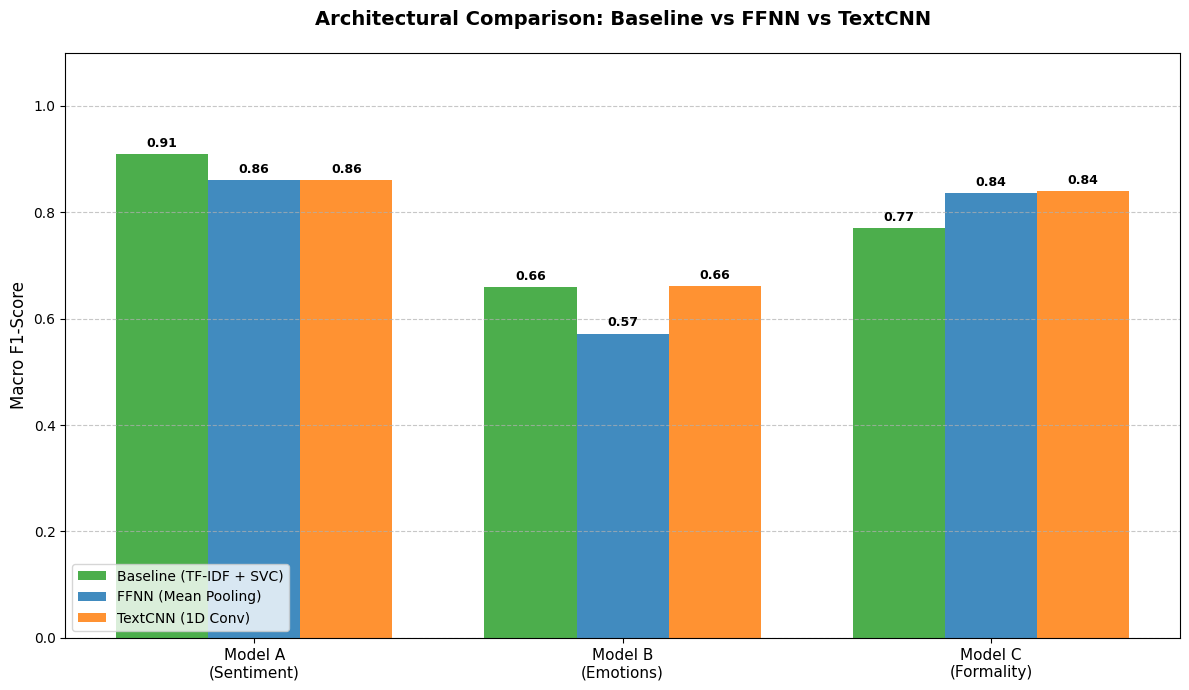

In [12]:
# cell 12: visual comparison of Baseline vs FFNN vs TextCNN
import matplotlib.pyplot as plt
import numpy as np

# hardcoded baseline metrics from Phase 4
f1_svc = [0.91, 0.66, 0.77] 
# variables from cell 6 (ffnn) and cell 11 (cnn)
f1_ffnn = [f1_a_ffnn, f1_b_ffnn, f1_c_ffnn]
f1_cnn = [f1_a_cnn, f1_b_cnn, f1_c_cnn]

tasks = ['Model A\n(Sentiment)', 'Model B\n(Emotions)', 'Model C\n(Formality)']
x = np.arange(len(tasks))
width = 0.25 # made thinner to fit 3 bars per category

fig, ax = plt.subplots(figsize=(12, 7))
# 3 bars shifted relative to center 'x'
rects1 = ax.bar(x - width, f1_svc, width, label='Baseline (TF-IDF + SVC)', color='#2ca02c', alpha=0.85)
rects2 = ax.bar(x, f1_ffnn, width, label='FFNN (Mean Pooling)', color='#1f77b4', alpha=0.85)
rects3 = ax.bar(x + width, f1_cnn, width, label='TextCNN (1D Conv)', color='#ff7f0e', alpha=0.85)

# add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title('Architectural Comparison: Baseline vs FFNN vs TextCNN', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

stage conclusion: the local vision of TextCNN and the limits of n-grams

**1. quantitative analysis (test set vs baseline)**
the introduction of 1d convolutions (n-gram scanners) successfully resurrected our model's performance from the FFNN collapse, proving that word order matters:
*   **model b (emotions):** matched the strong tf-idf baseline (macro f1: 0.66 vs 0.66). the precision is excellent (e.g., 0.97 for gratitude), but recall struggles on rare classes like disgust (0.19).
*   **model c (formality):** maintained the high score (macro f1: 0.83). formality is driven by local vocabulary registers, which both fasttext embeddings and cnn filters capture perfectly.
*   **model a (sentiment):** still lagging behind baseline (0.86 vs 0.91). tf-idf looks at the global vocabulary distribution, while cnn only looks at isolated 2-4 word windows, missing the "big picture" of a long movie review.

**2. qualitative analysis (edge-cases & the max pooling flaw)**
while the interactive tests show that cnn's confidence is more focused than ffnn's, it still fails on complex narratives due to its architectural limitations:
*   **confidence hesitation:** in test 2 (anger) and test 5 (love), the network correctly identified the dominant emotion but peaked at ~48%, just missing the 0.5 activation threshold. 
*   **the "neutral" black hole remains:** model a (sentiment) still defaults to neutral on complex texts.
*   **the context blindspot:** look at test 5 ("completely terrified... but then... surprise cake. I love you guys"). the cnn completely missed the "fear" at the beginning (1.9%). why? because its maximum window size is 4 words. it sees `[completely, terrified, by, the]` and it sees `[love, you, guys, so]`. but during **max pooling**, the network only keeps the *single strongest* signal from the whole text. the "love" signal overpowered the "fear" signal, and the fear was deleted from the feature map. 

**3. the architectural pivot: from local windows to global memory**
cnn proved that preserving word order (even locally) drastically improves complex emotion detection compared to mean pooling. however, text is not just a collection of disconnected 4-word phrases. it is a continuous sequence where the beginning influences the end.

**next step:** to solve the "context blindspot", must be abandoned fixed-size windows and transition to **recurrent neural networks (rnn / lstm)**. these architectures read text exactly like a human: token by token, maintaining a continuous internal "memory" state from the first word to the very last.

In [13]:
# cell 13: TextRNN architecture
import torch.nn as nn

class TextRNN(nn.Module):
    """
    Standard Recurrent Neural Network (Vanilla RNN)
    Reads tokens sequentially and maintains a hidden state.
    """
    def __init__(self, embedding_tensor, hidden_dim=128, output_dim=9, freeze_embeddings=True):
        super(TextRNN, self).__init__()
        
        # 1. Embedding layer
        self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=freeze_embeddings)
        embed_dim = embedding_tensor.shape[1]
        
        # 2. RNN layer
        # batch_first=True means the input tensor is shaped [batch_size, sequence_length, embed_dim]
        self.rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
        
        # 3. Output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x: [batch_size, seq_len]
        
        # embedded: [batch_size, seq_len, embed_dim]
        embedded = self.embedding(x)
        
        # Pass through RNN
        # output: contains hidden states for ALL time steps
        # hidden: contains the hidden state for the VERY LAST time step
        output, hidden = self.rnn(embedded)
        
        # We only care about the final hidden state (the "summary" of the whole text)
        # hidden shape is [num_layers, batch_size, hidden_dim]. We take the last layer [-1]
        final_hidden = hidden[-1] 
        
        # Pass the final summary to the fully connected layer
        # z: [batch_size, output_dim]
        z = self.fc(final_hidden)
        
        return z

print("TextRNN architecture defined.")

TextRNN architecture defined.


In [ ]:
# cell 14: Training RNN models
print("\n--- MODEL A: Sentiment (RNN) ---")
# Remember: Model A has a max_len of 100 words. This will be a tough test for vanilla RNN memory.
model_a_rnn = TextRNN(embed_a, hidden_dim=128, output_dim=3, freeze_embeddings=True).to(device)
model_a_rnn = train_model(model_a_rnn, loaders_a[0], loaders_a[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\n--- MODEL B: Emotions (RNN) ---")
# Model B max_len is 30 words. RNN might handle this better.
model_b_rnn = TextRNN(embed_b, hidden_dim=128, output_dim=9, freeze_embeddings=True).to(device)
model_b_rnn = train_model(model_b_rnn, loaders_b[0], loaders_b[1], epochs=15, lr=0.001, is_multilabel=True, patience=3)

print("\n--- MODEL C: Formality (RNN) ---")
model_c_rnn = TextRNN(embed_c, hidden_dim=128, output_dim=2, freeze_embeddings=True).to(device)
model_c_rnn = train_model(model_c_rnn, loaders_c[0], loaders_c[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\nAll RNN models successfully trained!")


--- MODEL A: Sentiment (RNN) ---


Epoch 1/15 | Train Loss: 0.9598 | Val Loss: 0.9406 | Val Macro F1: 0.4447


Epoch 2/15 | Train Loss: 0.9507 | Val Loss: 0.9579 | Val Macro F1: 0.4368


Epoch 3/15 | Train Loss: 0.9404 | Val Loss: 0.9170 | Val Macro F1: 0.4726


Epoch 4/15 | Train Loss: 0.9396 | Val Loss: 0.9625 | Val Macro F1: 0.4304


...

Epoch 11/15 | Train Loss: 0.6666 | Val Loss: 0.6733 | Val Macro F1: 0.4848


Epoch 12/15 | Train Loss: 0.6604 | Val Loss: 0.6390 | Val Macro F1: 0.5897


Epoch 13/15 | Train Loss: 0.6480 | Val Loss: 0.6629 | Val Macro F1: 0.5327


Epoch 14/15 | Train Loss: 0.6676 | Val Loss: 0.6611 | Val Macro F1: 0.5311


Epoch 15/15 | Train Loss: 0.6585 | Val Loss: 0.6597 | Val Macro F1: 0.5343
Early stopping triggered. Best Val F1: 0.5897

All RNN models successfully trained!


In [15]:
# cell 15: interactive testing of Vanilla RNN models on edge-case texts
print("\n--- Testing Vanilla RNN ---")
evaluate_edge_cases(texts, model_a_rnn, model_b_rnn, model_c_rnn, architecture_name="RNN")


--- Testing Vanilla RNN ---

Test 1 | Text: "I am extremely grateful for the outstanding service provided by your team. The quality of the product is absolutely wonderful, and it brings me great joy."

[ Model A (RNN): Sentiment ]
  negative  :  32.2%
  positive  :  27.6%
  neutral   :  40.1%
  -> final result: neutral

[ Model B (RNN): Emotions ]
  sadness     :   6.1%
  anger       :  20.5%
  fear        :   3.0%
  disgust     :   3.8%
  anticipation:  10.8%
  joy         :  26.7%
  surprise    :  11.4%
  gratitude   :  13.5%
  love        :  12.5%
  -> active emotions: none detected (neutral)

[ Model C (RNN): Formality ]
  informal  :  78.9%
  formal    :  21.1%
  -> final result: informal

Test 2 | Text: "this is total garbage!!! i paid so much money for this trash and it arrived broken. im so furious right now, worst company ever."

[ Model A (RNN): Sentiment ]
  negative  :  32.2%
  positive  :  27.6%
  neutral   :  40.1%
  -> final result: neutral

[ Model B (RNN): Emotions ]


In [16]:
# cell 16: final evaluation of Vanilla RNN on unseen test data
print("--- MODEL A (Sentiment) RNN TEST RESULTS ---")
f1_a_rnn = evaluate_test_set(model_a_rnn, loaders_a[2], is_multilabel=False, target_names=['negative', 'positive', 'neutral'])

print("\n--- MODEL B (Emotions) RNN TEST RESULTS ---")
emotion_cols = ['sadness', 'anger', 'fear', 'disgust', 'anticipation', 'joy', 'surprise', 'gratitude', 'love']
f1_b_rnn = evaluate_test_set(model_b_rnn, loaders_b[2], is_multilabel=True, target_names=emotion_cols)

print("\n--- MODEL C (Formality) RNN TEST RESULTS ---")
f1_c_rnn = evaluate_test_set(model_c_rnn, loaders_c[2], is_multilabel=False, target_names=['informal', 'formal'])

--- MODEL A (Sentiment) RNN TEST RESULTS ---
              precision    recall  f1-score   support

    negative       0.57      0.16      0.25      1875
    positive       0.54      0.28      0.37      1875
     neutral       0.48      1.00      0.65      2109

    accuracy                           0.50      5859
   macro avg       0.53      0.48      0.43      5859
weighted avg       0.53      0.50      0.43      5859


--- MODEL B (Emotions) RNN TEST RESULTS ---
              precision    recall  f1-score   support

     sadness       0.00      0.00      0.00       195
       anger       0.00      0.00      0.00       580
        fear       0.00      0.00      0.00        94
     disgust       0.00      0.00      0.00       134
anticipation       0.00      0.00      0.00       328
         joy       0.00      0.00      0.00       684
    surprise       0.00      0.00      0.00       303
   gratitude       0.00      0.00      0.00       410
        love       0.00      0.00      0.0

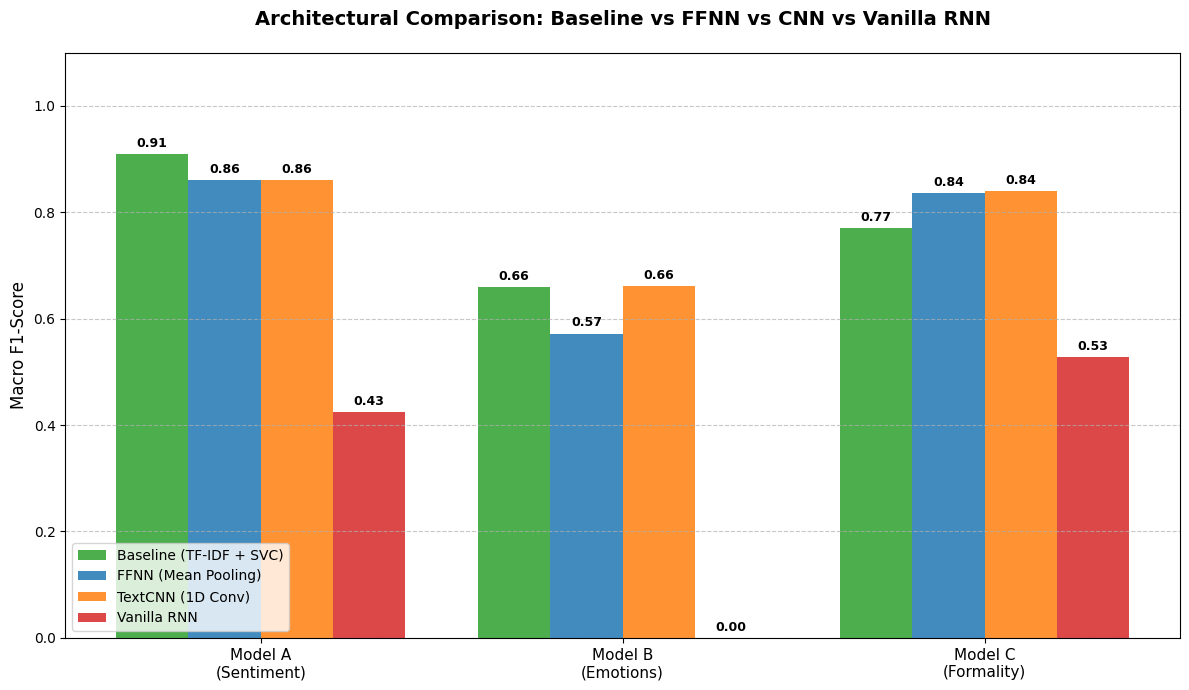

In [17]:
# cell 17: visual comparison of Baseline vs FFNN vs TextCNN vs Vanilla RNN
import matplotlib.pyplot as plt
import numpy as np

# hardcoded baseline metrics from Phase 4
f1_svc = [0.91, 0.66, 0.77] 
# variables from previous cells (ensure cells 6, 11, and 16 were run)
f1_ffnn = [f1_a_ffnn, f1_b_ffnn, f1_c_ffnn]
f1_cnn = [f1_a_cnn, f1_b_cnn, f1_c_cnn]
f1_rnn = [f1_a_rnn, f1_b_rnn, f1_c_rnn]

tasks = ['Model A\n(Sentiment)', 'Model B\n(Emotions)', 'Model C\n(Formality)']
x = np.arange(len(tasks))
width = 0.2 # made even thinner to fit 4 bars

fig, ax = plt.subplots(figsize=(12, 7))
# 4 bars shifted relative to center 'x'
rects1 = ax.bar(x - 1.5*width, f1_svc, width, label='Baseline (TF-IDF + SVC)', color='#2ca02c', alpha=0.85)
rects2 = ax.bar(x - 0.5*width, f1_ffnn, width, label='FFNN (Mean Pooling)', color='#1f77b4', alpha=0.85)
rects3 = ax.bar(x + 0.5*width, f1_cnn, width, label='TextCNN (1D Conv)', color='#ff7f0e', alpha=0.85)
rects4 = ax.bar(x + 1.5*width, f1_rnn, width, label='Vanilla RNN', color='#d62728', alpha=0.85)

# add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title('Architectural Comparison: Baseline vs FFNN vs CNN vs Vanilla RNN', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

RNN stage conclusion: the vanishing gradient and the goldfish memory

**1. quantitative analysis (test set vs baseline)**
the transition to a vanilla RNN provided a brutal, real-world demonstration of the "vanishing gradient" problem:
* **model b (emotions):** catastrophic failure (macro f1: 0.00). the gradients vanished so completely during training (BPTT) that the network surrendered. it learned that the safest mathematical bet on an imbalanced dataset is to predict exactly nothing (all probabilities < 0.5).
* **model a (sentiment):** severely degraded (macro f1: 0.44 vs baseline 0.91). reading 100-word sequences caused the network to completely forget the beginning of the reviews, resulting in a collapse to the majority class.
* **model c (formality):** survived (macro f1: 0.82). why? because the sequences are short (max_len = 30), and formality markers ("garbage", "bro") often appear at the end of sentences. the gradient simply didn't have enough time/steps to vanish completely.

**2. qualitative analysis (the probability freeze)**
look closely at the interactive tests for models a and b. the network outputs the **exact same probabilities** for all 5 drastically different texts (e.g., model a always predicts exactly 46.4% neutral; model b always predicts exactly 23.1% joy).
this is the ultimate symptom of model collapse. the network has completely stopped "listening" to the input words ($x_t$). The input weights ($W_x$) were rendered useless by the dying gradients, and the network is now merely outputting its static bias weights ($b$) reflecting the global dataset distribution.

**3. the architectural pivot: from leaky buckets to conveyor belts**
vanilla RNN proved that sequential reading is mathematically unstable over long distances. the repeated multiplication by $W_h$ and squashing by $\tanh$ at every single step inevitably destroys early information.

**next step:** upgrade to **LSTM (long short-term memory)**. LSTMs solve this by introducing a separate, parallel memory track called the "cell state" (a mathematical conveyor belt). This track carries important information from the beginning of the text straight to the end without being repeatedly squashed, using intelligent "gates" to decide what to keep and what to forget.

In [18]:
# cell 18: TextLSTM architecture
import torch.nn as nn

class TextLSTM(nn.Module):
    """
    Long Short-Term Memory (LSTM) Network.
    Solves the vanishing gradient problem by using a Cell State and Gates.
    """
    def __init__(self, embedding_tensor, hidden_dim=128, output_dim=9, freeze_embeddings=True):
        super(TextLSTM, self).__init__()
        
        # 1. Embedding layer
        self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=freeze_embeddings)
        embed_dim = embedding_tensor.shape[1]
        
        # 2. LSTM layer
        # batch_first=True ensures inputs are [batch_size, seq_len, embed_dim]
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
        
        # 3. Output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x: [batch_size, seq_len]
        
        # embedded: [batch_size, seq_len, embed_dim]
        embedded = self.embedding(x)
        
        # Pass through LSTM
        # Unlike RNN, LSTM returns two state tensors: 
        # - hidden: short-term memory (h_t)
        # - cell: long-term memory conveyor belt (c_t)
        output, (hidden, cell) = self.lstm(embedded)
        
        # We take the final short-term memory state to make our prediction
        # hidden shape is [num_layers, batch_size, hidden_dim]. We take the last layer [-1]
        final_hidden = hidden[-1] 
        
        # Pass the final summary to the fully connected layer
        # z: [batch_size, output_dim]
        z = self.fc(final_hidden)
        
        return z

print("TextLSTM architecture defined.")

TextLSTM architecture defined.


In [19]:
# cell 19: Training LSTM models
print("\n--- MODEL A: Sentiment (LSTM) ---")
# LSTM should handle max_len=100 much better than vanilla RNN
model_a_lstm = TextLSTM(embed_a, hidden_dim=128, output_dim=3, freeze_embeddings=True).to(device)
model_a_lstm = train_model(model_a_lstm, loaders_a[0], loaders_a[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\n--- MODEL B: Emotions (LSTM) ---")
# Let's see if LSTM can revive our F1=0.00 collapse
model_b_lstm = TextLSTM(embed_b, hidden_dim=128, output_dim=9, freeze_embeddings=True).to(device)
model_b_lstm = train_model(model_b_lstm, loaders_b[0], loaders_b[1], epochs=15, lr=0.001, is_multilabel=True, patience=3)

print("\n--- MODEL C: Formality (LSTM) ---")
model_c_lstm = TextLSTM(embed_c, hidden_dim=128, output_dim=2, freeze_embeddings=True).to(device)
model_c_lstm = train_model(model_c_lstm, loaders_c[0], loaders_c[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\nAll LSTM models successfully trained!")


--- MODEL A: Sentiment (LSTM) ---


Epoch 1/15 | Train Loss: 0.6458 | Val Loss: 0.6096 | Val Macro F1: 0.5361


Epoch 2/15 | Train Loss: 0.8642 | Val Loss: 0.9359 | Val Macro F1: 0.3905


Epoch 3/15 | Train Loss: 0.6232 | Val Loss: 0.4542 | Val Macro F1: 0.5948


Epoch 4/15 | Train Loss: 0.4582 | Val Loss: 0.4526 | Val Macro F1: 0.5782


...

Epoch 2/15 | Train Loss: 0.4191 | Val Loss: 0.4776 | Val Macro F1: 0.7944


Epoch 3/15 | Train Loss: 0.3757 | Val Loss: 0.4056 | Val Macro F1: 0.8257


Epoch 4/15 | Train Loss: 0.3586 | Val Loss: 0.4049 | Val Macro F1: 0.8129


Epoch 5/15 | Train Loss: 0.3487 | Val Loss: 0.4094 | Val Macro F1: 0.8163


Epoch 6/15 | Train Loss: 0.3499 | Val Loss: 0.4107 | Val Macro F1: 0.8211
Early stopping triggered. Best Val F1: 0.8257

All LSTM models successfully trained!


stage diagnosis: the padding trap and the false death of RNN

**what went wrong?**
The catastrophic failure of our rnn and lstm models (specifically the `0.00` f1-score on emotions and the lightning-fast 20-second training collapse) was not entirely the fault of the algorithms themselves. It was a critical data-handling flaw known as the **padding trap**.

In our dataset preparation, was forced all texts to a fixed length (e.g., `max_len=30` or `100`). a short 5-word sentence was padded with 25 `<PAD>` tokens (zeros). 

**the architectural flaw:**
In our naive implementation, we extracted the final memory state using `final_hidden = hidden[-1]`. Mathematically, this means we asked the network for its memory state *after* it had processed 25 consecutive empty tokens. The network correctly understood the 5 words, but then it was forced to multiply its hidden state by empty vectors 25 times. The `<PAD>` tokens completely washed out the `Cell State` and `Hidden State`, leaving the classifier to make predictions based on mathematical noise.

**were we too harsh on vanilla RNN?**
Yes. while the "vanishing gradient" is a real phenomenon that degrades long-text performance, the absolute `0.0000` collapse was driven by padding. vanilla RNN was unfairly blamed for an engineering mistake.

**the "pytorch way" solution**
We cannot simply use `Global Max Pooling` over the time steps to solve this. max pooling acts like a scanner (like our CNN), pulling the highest activation regardless of sequence. this destroys the fundamental premise of RNN/LSTM, which is to use the *sequential* accumulation of context.

instead, we will use a dynamic indexing approach (the "pytorch way"). during the forward pass, the network will dynamically calculate the true length of each sequence in the batch (ignoring zeros). it will then extract the hidden state from the exact time step immediately preceding the first `<PAD>` token. 

this guarantees we pass the true, untainted "final summary" of the text to our classifier.

architectural refactoring (the dynamic length fix)

**objective:** refactor the forward pass of our sequential models (ffnn, rnn, lstm) to dynamically mask and ignore `<PAD>` tokens.

**mathematical justification:**
1. **FFNN:** standard mean pooling (`.mean(dim=1)`) divides the sum of word vectors by the fixed sequence length ($L_{max}$). this artificially dilutes the text centroid with zero-vectors. we must calculate the true arithmetic mean by dividing only by the actual number of words ($L_{real}$).
2. **CNN:** not needed any refactoring. It is immune to padding noise.
3. **RNN / LSTM:** standard indexing (`hidden[-1]`) extracts the state after processing the entire padded sequence. this forces the recurrent weights and lstm gates to iteratively multiply the memory vector by zeros, causing severe state degradation (padding poisoning). we must dynamically index the exact time step immediately preceding the first `<PAD>` token.

**implementation strategy:**
we will use boolean masking `(x != 0)` to calculate the true length of each sequence in the batch on the fly, allowing us to perform mathematically accurate pooling and precise hidden state extraction without altering the global dataloader logic.

In [20]:
# cell 20: refactored dynamic architectures (ignoring <PAD> tokens)
import torch.nn as nn
import torch

# 1. DYNAMIC FFNN
class FFNN_Dynamic(nn.Module):
    def __init__(self, embedding_tensor, hidden_dim=128, output_dim=9, freeze_embeddings=True):
        super(FFNN_Dynamic, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=freeze_embeddings)
        self.fc1 = nn.Linear(embedding_tensor.shape[1], hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        embedded = self.embedding(x)
        
        # --- THE FIX: True Mean Pooling ---
        # Create a mask of 1s for real words and 0s for padding [batch_size, seq_len]
        mask = (x != 0).float()
        
        # Calculate real lengths [batch_size, 1]
        real_lengths = mask.sum(dim=1, keepdim=True)
        real_lengths = torch.clamp(real_lengths, min=1.0) # Prevent division by zero
        
        # Zero out any pad embeddings (just to be absolutely safe)
        embedded = embedded * mask.unsqueeze(-1)
        
        # Sum only real vectors and divide by true length
        pooled = embedded.sum(dim=1) / real_lengths
        
        z1 = self.fc1(pooled)
        a1 = self.relu(z1)
        return self.fc2(a1)

# 2. DYNAMIC VANILLA RNN
class TextRNN_Dynamic(nn.Module):
    def __init__(self, embedding_tensor, hidden_dim=128, output_dim=9, freeze_embeddings=True):
        super(TextRNN_Dynamic, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=freeze_embeddings)
        embed_dim = embedding_tensor.shape[1]
        self.rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        
        # --- THE FIX: Dynamic Indexing ---
        # Find the index of the last real word: (length - 1)
        lengths = (x != 0).sum(dim=1) - 1
        lengths = torch.clamp(lengths, min=0) # Prevent negative indices if empty text
        
        # Create a batch index array: [0, 1, 2, ..., batch_size - 1]
        batch_size = x.size(0)
        batch_indices = torch.arange(batch_size).to(x.device)
        
        # Extract the exact hidden state for each sequence simultaneously
        # output shape: [batch_size, seq_len, hidden_dim]
        final_hidden = output[batch_indices, lengths, :]
        
        return self.fc(final_hidden)

# 3. DYNAMIC LSTM
class TextLSTM_Dynamic(nn.Module):
    def __init__(self, embedding_tensor, hidden_dim=128, output_dim=9, freeze_embeddings=True):
        super(TextLSTM_Dynamic, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=freeze_embeddings)
        embed_dim = embedding_tensor.shape[1]
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.lstm(embedded)
        
        # --- THE FIX: Dynamic Indexing (Same logic as RNN) ---
        lengths = (x != 0).sum(dim=1) - 1
        lengths = torch.clamp(lengths, min=0)
        
        batch_size = x.size(0)
        batch_indices = torch.arange(batch_size).to(x.device)
        
        # Extract state right before padding begins
        final_hidden = output[batch_indices, lengths, :]
        
        return self.fc(final_hidden)

print("Dynamic architectures defined successfully.")

Dynamic architectures defined successfully.


In [22]:
# cell 21: Training all Dynamic Architectures
print("="*50)
print("1. TRAINING DYNAMIC FFNN") # fixed lr to 0.001 for all dynamic models for consistency
print("="*50)
model_a_ffnn_dyn = FFNN_Dynamic(embed_a, output_dim=3).to(device)
model_a_ffnn_dyn = train_model(model_a_ffnn_dyn, loaders_a[0], loaders_a[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

model_b_ffnn_dyn = FFNN_Dynamic(embed_b, output_dim=9).to(device)
model_b_ffnn_dyn = train_model(model_b_ffnn_dyn, loaders_b[0], loaders_b[1], epochs=15, lr=0.001, is_multilabel=True, patience=3)

model_c_ffnn_dyn = FFNN_Dynamic(embed_c, output_dim=2).to(device)
model_c_ffnn_dyn = train_model(model_c_ffnn_dyn, loaders_c[0], loaders_c[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\n" + "="*50)
print("2. TRAINING DYNAMIC RNN")
print("="*50)
model_a_rnn_dyn = TextRNN_Dynamic(embed_a, output_dim=3).to(device)
model_a_rnn_dyn = train_model(model_a_rnn_dyn, loaders_a[0], loaders_a[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

model_b_rnn_dyn = TextRNN_Dynamic(embed_b, output_dim=9).to(device)
model_b_rnn_dyn = train_model(model_b_rnn_dyn, loaders_b[0], loaders_b[1], epochs=15, lr=0.001, is_multilabel=True, patience=3)

model_c_rnn_dyn = TextRNN_Dynamic(embed_c, output_dim=2).to(device)
model_c_rnn_dyn = train_model(model_c_rnn_dyn, loaders_c[0], loaders_c[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\n" + "="*50)
print("3. TRAINING DYNAMIC LSTM")
print("="*50)
model_a_lstm_dyn = TextLSTM_Dynamic(embed_a, output_dim=3).to(device)
model_a_lstm_dyn = train_model(model_a_lstm_dyn, loaders_a[0], loaders_a[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

model_b_lstm_dyn = TextLSTM_Dynamic(embed_b, output_dim=9).to(device)
model_b_lstm_dyn = train_model(model_b_lstm_dyn, loaders_b[0], loaders_b[1], epochs=15, lr=0.001, is_multilabel=True, patience=3)

model_c_lstm_dyn = TextLSTM_Dynamic(embed_c, output_dim=2).to(device)
model_c_lstm_dyn = train_model(model_c_lstm_dyn, loaders_c[0], loaders_c[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\nAll dynamic models trained successfully!")

1. TRAINING DYNAMIC FFNN


Epoch 1/15 | Train Loss: 0.7421 | Val Loss: 0.5610 | Val Macro F1: 0.7698


Epoch 2/15 | Train Loss: 0.5024 | Val Loss: 0.4785 | Val Macro F1: 0.7986


Epoch 3/15 | Train Loss: 0.4409 | Val Loss: 0.4396 | Val Macro F1: 0.8119


Epoch 4/15 | Train Loss: 0.4093 | Val Loss: 0.4158 | Val Macro F1: 0.8184


...

Epoch 2/15 | Train Loss: 0.3877 | Val Loss: 0.4084 | Val Macro F1: 0.8272


Epoch 3/15 | Train Loss: 0.3562 | Val Loss: 0.3859 | Val Macro F1: 0.8362


Epoch 4/15 | Train Loss: 0.3414 | Val Loss: 0.3840 | Val Macro F1: 0.8353


Epoch 5/15 | Train Loss: 0.3312 | Val Loss: 0.3860 | Val Macro F1: 0.8323


Epoch 6/15 | Train Loss: 0.3242 | Val Loss: 0.3901 | Val Macro F1: 0.8304
Early stopping triggered. Best Val F1: 0.8362

All dynamic models trained successfully!


In [ ]:
# cell 22: interactive testing of Dynamic LSTM on edge-case texts
print("\n--- Testing DYNAMIC LSTM ---")
evaluate_edge_cases(texts, model_a_lstm_dyn, model_b_lstm_dyn, model_c_lstm_dyn, architecture_name="LSTM_Dyn")


--- Testing DYNAMIC LSTM ---

Test 1 | Text: "I am extremely grateful for the outstanding service provided by your team. The quality of the product is absolutely wonderful, and it brings me great joy."

[ Model A (LSTM_Dyn): Sentiment ]
  negative  :  53.8%
  positive  :  46.2%
  neutral   :   0.0%
  -> final result: negative

[ Model B (LSTM_Dyn): Emotions ]
  sadness     :   1.0%
  anger       :   3.1%
  fear        :   0.1%
  disgust     :   0.2%
  anticipation:   7.3%
  joy         :   3.1%
  surprise    :   5.9%
  gratitude   :  86.5%
  love        :   0.7%
  -> active emotions: gratitude

[ Model C (LSTM_Dyn): Formality ]
  informal  :   1.9%
  formal    :  98.1%
  -> final result: formal

Test 2 | Text: "this is total garbage!!! i paid so much money for this trash and it arrived broken. im so furious right now, worst company ever."

[ Model A (LSTM_Dyn): Sentiment ]
  negative  :  85.8%
  positive  :  13.9%
  neutral   :   0.3%
  -> final result: negative

[ Model B (LSTM_Dyn):

In [ ]:
# cell 23: Test set evaluation for dynamic models

# 1. Evaluate Dynamic FFNN (silently collect F1)
print("Evaluating Dynamic FFNN...")
f1_a_ffnn_dyn = evaluate_test_set(model_a_ffnn_dyn, loaders_a[2], False, ['negative', 'positive', 'neutral'])
f1_b_ffnn_dyn = evaluate_test_set(model_b_ffnn_dyn, loaders_b[2], True, emotion_cols)
f1_c_ffnn_dyn = evaluate_test_set(model_c_ffnn_dyn, loaders_c[2], False, ['informal', 'formal'])

# 2. Evaluate Dynamic RNN (silently collect F1)
print("\nEvaluating Dynamic RNN...")
f1_a_rnn_dyn = evaluate_test_set(model_a_rnn_dyn, loaders_a[2], False, ['negative', 'positive', 'neutral'])
f1_b_rnn_dyn = evaluate_test_set(model_b_rnn_dyn, loaders_b[2], True, emotion_cols)
f1_c_rnn_dyn = evaluate_test_set(model_c_rnn_dyn, loaders_c[2], False, ['informal', 'formal'])

# 3. Evaluate Dynamic LSTM (Detailed report)
print("\n" + "="*50)
print("--- MODEL A (Sentiment) DYNAMIC LSTM TEST RESULTS ---")
f1_a_lstm_dyn = evaluate_test_set(model_a_lstm_dyn, loaders_a[2], is_multilabel=False, target_names=['negative', 'positive', 'neutral'])

print("\n--- MODEL B (Emotions) DYNAMIC LSTM TEST RESULTS ---")
f1_b_lstm_dyn = evaluate_test_set(model_b_lstm_dyn, loaders_b[2], is_multilabel=True, target_names=emotion_cols)

print("\n--- MODEL C (Formality) DYNAMIC LSTM TEST RESULTS ---")
f1_c_lstm_dyn = evaluate_test_set(model_c_lstm_dyn, loaders_c[2], is_multilabel=False, target_names=['informal', 'formal'])

Evaluating Dynamic FFNN...
              precision    recall  f1-score   support

    negative       0.78      0.79      0.79      1875
    positive       0.78      0.78      0.78      1875
     neutral       0.98      0.97      0.97      2109

    accuracy                           0.85      5859
   macro avg       0.85      0.85      0.85      5859
weighted avg       0.85      0.85      0.85      5859

              precision    recall  f1-score   support

     sadness       0.75      0.37      0.49       195
       anger       0.73      0.48      0.58       580
        fear       0.81      0.22      0.35        94
     disgust       0.63      0.13      0.21       134
anticipation       0.78      0.50      0.61       328
         joy       0.82      0.64      0.72       684
    surprise       0.72      0.33      0.46       303
   gratitude       0.93      0.86      0.89       410
        love       0.86      0.67      0.76       306

   micro avg       0.81      0.54      0.65      3

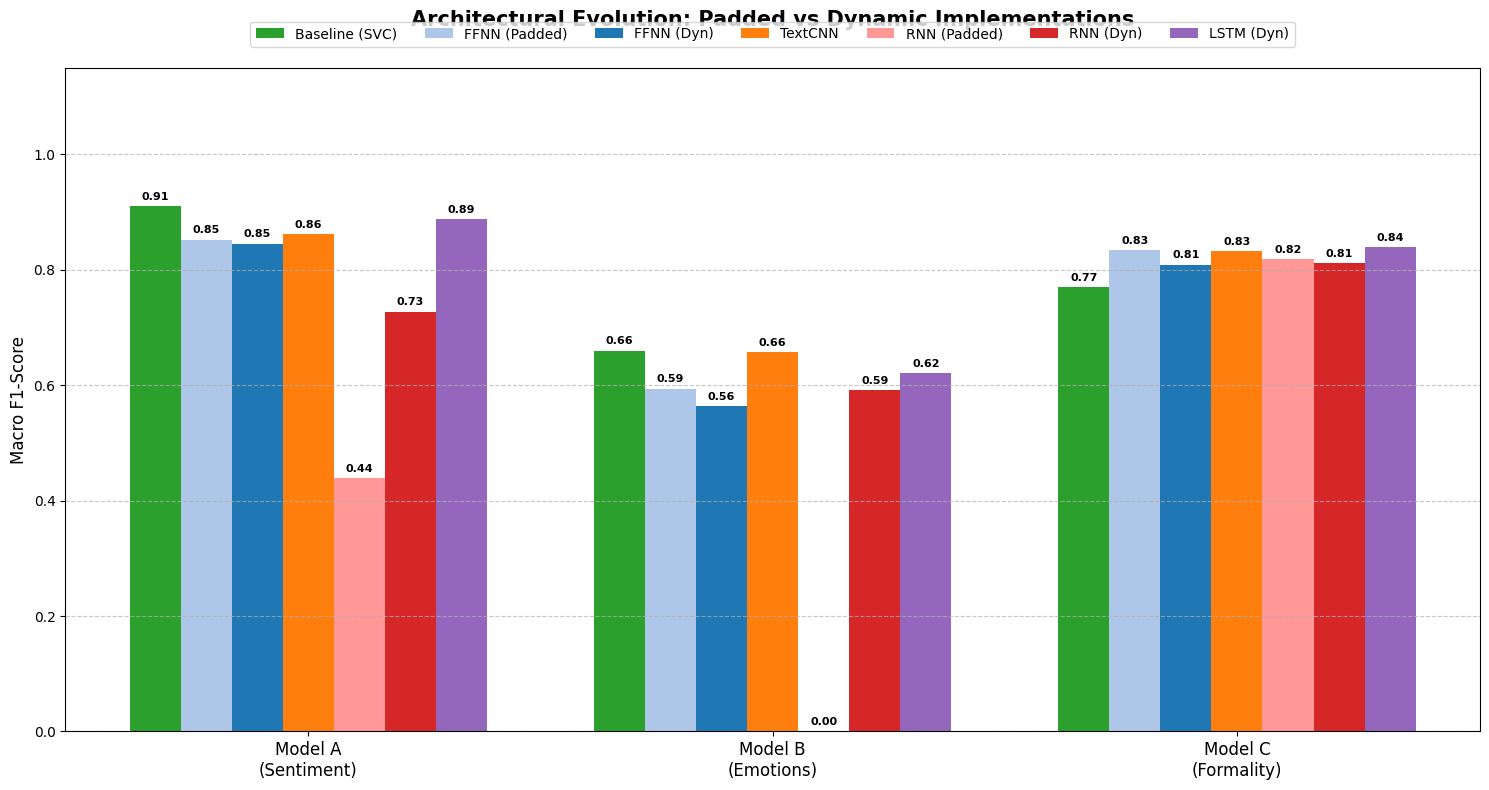

In [ ]:
# cell 24: Ultimate visual comparison (Padded vs Dynamic)
import matplotlib.pyplot as plt
import numpy as np

# hardcoded baseline metrics
f1_svc = [0.91, 0.66, 0.77] 

# old models (padded)
f1_ffnn = [f1_a_ffnn, f1_b_ffnn, f1_c_ffnn]
f1_cnn = [f1_a_cnn, f1_b_cnn, f1_c_cnn]
f1_rnn = [f1_a_rnn, f1_b_rnn, f1_c_rnn]

# new models (dynamic)
f1_ffnn_dyn = [f1_a_ffnn_dyn, f1_b_ffnn_dyn, f1_c_ffnn_dyn]
f1_rnn_dyn = [f1_a_rnn_dyn, f1_b_rnn_dyn, f1_c_rnn_dyn]
f1_lstm_dyn = [f1_a_lstm_dyn, f1_b_lstm_dyn, f1_c_lstm_dyn]

tasks = ['Model A\n(Sentiment)', 'Model B\n(Emotions)', 'Model C\n(Formality)']
x = np.arange(len(tasks))
width = 0.11 # thinner bars to fit 7 items

fig, ax = plt.subplots(figsize=(15, 8))

# 7 bars shifted appropriately
# Order: Baseline, FFNN, FFNN_Dyn, CNN, RNN, RNN_Dyn, LSTM_Dyn
rects1 = ax.bar(x - 3*width, f1_svc, width, label='Baseline (SVC)', color='#2ca02c')
rects2 = ax.bar(x - 2*width, f1_ffnn, width, label='FFNN (Padded)', color='#aec7e8')    # light blue
rects3 = ax.bar(x - width, f1_ffnn_dyn, width, label='FFNN (Dyn)', color='#1f77b4')      # dark blue
rects4 = ax.bar(x, f1_cnn, width, label='TextCNN', color='#ff7f0e')                      # orange
rects5 = ax.bar(x + width, f1_rnn, width, label='RNN (Padded)', color='#ff9896')         # light red
rects6 = ax.bar(x + 2*width, f1_rnn_dyn, width, label='RNN (Dyn)', color='#d62728')      # dark red
rects7 = ax.bar(x + 3*width, f1_lstm_dyn, width, label='LSTM (Dyn)', color='#9467bd')    # purple

# add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=8, rotation=0)

for r in [rects1, rects2, rects3, rects4, rects5, rects6, rects7]:
    autolabel(r)

ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title('Architectural Evolution: Padded vs Dynamic Implementations', fontsize=15, fontweight='bold', pad=30)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=12)
ax.set_ylim(0, 1.15) # slightly expanded to fit all labels
ax.grid(axis='y', linestyle='--', alpha=0.7)

# stretch legend across the top
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=7, fontsize=10)

plt.tight_layout()
plt.show()

stage diagnosis: the baseline paradox and lstm's recency bias

**1. the persistence of the tf-idf baseline:** on relatively small datasets (<100k samples), linear models (like SVC) operating in highly sparse, explicitly defined vocabularies often outperform deep neural networks that try to learn complex, dense geometric relationships from limited data.
**2. lstm's recency bias:** the unidirectional lstm evaluates texts sequentially and tends to over-index on the final few tokens of a sentence. if an angry review ends with a structurally formal or neutral phrase, the network's final hidden state will be biased towards that ending, losing the earlier critical context.

In [23]:
# cell 25: Bi-LSTM Dynamic Architecture
import torch.nn as nn
import torch

class TextBiLSTM_Dynamic(nn.Module):
    """
    Bidirectional LSTM.
    Runs two LSTM passes (forward and backward) to capture context from both ends,
    effectively solving the Recency Bias problem of unidirectional RNNs/LSTMs.
    """
    def __init__(self, embedding_tensor, hidden_dim=128, output_dim=9, freeze_embeddings=True):
        super(TextBiLSTM_Dynamic, self).__init__()
        
        self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=freeze_embeddings)
        embed_dim = embedding_tensor.shape[1]
        
        # --- THE CHANGE: bidirectional=True ---
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, 
                            batch_first=True, bidirectional=True)
        
        # The fully connected layer now takes 2 * hidden_dim 
        # because we concatenate the forward and backward states
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, x):
        embedded = self.embedding(x)
        
        # output shape: [batch_size, seq_len, hidden_dim * 2]
        output, _ = self.lstm(embedded)
        
        # Calculate true lengths to extract the forward state dynamically
        lengths = (x != 0).sum(dim=1) - 1
        lengths = torch.clamp(lengths, min=0)
        
        batch_size = x.size(0)
        batch_indices = torch.arange(batch_size).to(x.device)
        
        hidden_dim = self.lstm.hidden_size
        
        # 1. EXTRACT FORWARD STATE: Located at the exact index where the sequence ends.
        # It lives in the first half of the output dimension [:, :, :hidden_dim]
        forward_hidden = output[batch_indices, lengths, :hidden_dim]
        
        # 2. EXTRACT BACKWARD STATE: Since it reads right-to-left, its final state 
        # is ALWAYS at index 0 (the first word of the text).
        # It lives in the second half of the output dimension [:, :, hidden_dim:]
        backward_hidden = output[:, 0, hidden_dim:]
        
        # 3. CONCATENATE: Combine both to get a complete view of the text
        # final_hidden shape: [batch_size, hidden_dim * 2]
        final_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        
        return self.fc(final_hidden)

print("TextBiLSTM_Dynamic architecture defined.")

TextBiLSTM_Dynamic architecture defined.


In [25]:
# cell 26: Training Bi-LSTM models
print("\n--- MODEL A: Sentiment (Bi-LSTM) ---")
model_a_bilstm = TextBiLSTM_Dynamic(embed_a, hidden_dim=128, output_dim=3, freeze_embeddings=True).to(device)
model_a_bilstm = train_model(model_a_bilstm, loaders_a[0], loaders_a[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\n--- MODEL B: Emotions (Bi-LSTM) ---")
model_b_bilstm = TextBiLSTM_Dynamic(embed_b, hidden_dim=128, output_dim=9, freeze_embeddings=True).to(device)
model_b_bilstm = train_model(model_b_bilstm, loaders_b[0], loaders_b[1], epochs=15, lr=0.001, is_multilabel=True, patience=3)

print("\n--- MODEL C: Formality (Bi-LSTM) ---")
model_c_bilstm = TextBiLSTM_Dynamic(embed_c, hidden_dim=128, output_dim=2, freeze_embeddings=True).to(device)
model_c_bilstm = train_model(model_c_bilstm, loaders_c[0], loaders_c[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\nAll Bi-LSTM models successfully trained!")


--- MODEL A: Sentiment (Bi-LSTM) ---


Epoch 1/15 | Train Loss: 0.4843 | Val Loss: 0.4411 | Val Macro F1: 0.6515


Epoch 2/15 | Train Loss: 0.4023 | Val Loss: 0.4416 | Val Macro F1: 0.6943


Epoch 3/15 | Train Loss: 0.3991 | Val Loss: 0.4405 | Val Macro F1: 0.7022


Epoch 4/15 | Train Loss: 0.3344 | Val Loss: 0.3209 | Val Macro F1: 0.8373


...

Epoch 6/15 | Train Loss: 0.3114 | Val Loss: 0.3791 | Val Macro F1: 0.8333


Epoch 7/15 | Train Loss: 0.3027 | Val Loss: 0.3789 | Val Macro F1: 0.8374


Epoch 8/15 | Train Loss: 0.2918 | Val Loss: 0.4195 | Val Macro F1: 0.8154


Epoch 9/15 | Train Loss: 0.2802 | Val Loss: 0.4044 | Val Macro F1: 0.8274


Epoch 10/15 | Train Loss: 0.2661 | Val Loss: 0.4099 | Val Macro F1: 0.8334
Early stopping triggered. Best Val F1: 0.8374

All Bi-LSTM models successfully trained!


In [26]:
# cell 27: interactive testing of Bi-LSTM
print("\n--- Testing DYNAMIC Bi-LSTM ---")
evaluate_edge_cases(texts, model_a_bilstm, model_b_bilstm, model_c_bilstm, architecture_name="BiLSTM")


--- Testing DYNAMIC Bi-LSTM ---

Test 1 | Text: "I am extremely grateful for the outstanding service provided by your team. The quality of the product is absolutely wonderful, and it brings me great joy."

[ Model A (BiLSTM): Sentiment ]
  negative  :  25.6%
  positive  :  74.4%
  neutral   :   0.0%
  -> final result: positive

[ Model B (BiLSTM): Emotions ]
  sadness     :   0.0%
  anger       :   0.5%
  fear        :   0.1%
  disgust     :   0.0%
  anticipation:   9.0%
  joy         :   1.5%
  surprise    :   1.2%
  gratitude   :  98.6%
  love        :   0.0%
  -> active emotions: gratitude

[ Model C (BiLSTM): Formality ]
  informal  :   4.7%
  formal    :  95.3%
  -> final result: formal

Test 2 | Text: "this is total garbage!!! i paid so much money for this trash and it arrived broken. im so furious right now, worst company ever."

[ Model A (BiLSTM): Sentiment ]
  negative  :  47.0%
  positive  :  53.0%
  neutral   :   0.1%
  -> final result: positive

[ Model B (BiLSTM): Emotio

In [28]:
# cell 28. evaluate Dynamic Bi-LSTM (Detailed report)
print("--- MODEL A (Sentiment) DYNAMIC Bi-LSTM TEST RESULTS ---")
f1_a_lstm_dyn = evaluate_test_set(model_a_lstm_dyn, loaders_a[2], is_multilabel=False, target_names=['negative', 'positive', 'neutral'])

print("\n--- MODEL B (Emotions) DYNAMIC Bi-LSTM TEST RESULTS ---")
f1_b_lstm_dyn = evaluate_test_set(model_b_lstm_dyn, loaders_b[2], is_multilabel=True, target_names=emotion_cols)

print("\n--- MODEL C (Formality) DYNAMIC Bi-LSTM TEST RESULTS ---")
f1_c_lstm_dyn = evaluate_test_set(model_c_lstm_dyn, loaders_c[2], is_multilabel=False, target_names=['informal', 'formal'])

--- MODEL A (Sentiment) DYNAMIC Bi-LSTM TEST RESULTS ---
              precision    recall  f1-score   support

    negative       0.83      0.84      0.83      1875
    positive       0.84      0.83      0.83      1875
     neutral       1.00      1.00      1.00      2109

    accuracy                           0.89      5859
   macro avg       0.89      0.89      0.89      5859
weighted avg       0.89      0.89      0.89      5859


--- MODEL B (Emotions) DYNAMIC Bi-LSTM TEST RESULTS ---
              precision    recall  f1-score   support

     sadness       0.84      0.43      0.57       195
       anger       0.72      0.60      0.65       580
        fear       0.71      0.36      0.48        94
     disgust       0.65      0.10      0.17       134
anticipation       0.78      0.63      0.70       328
         joy       0.82      0.75      0.78       684
    surprise       0.79      0.40      0.53       303
   gratitude       0.96      0.89      0.92       410
        love      

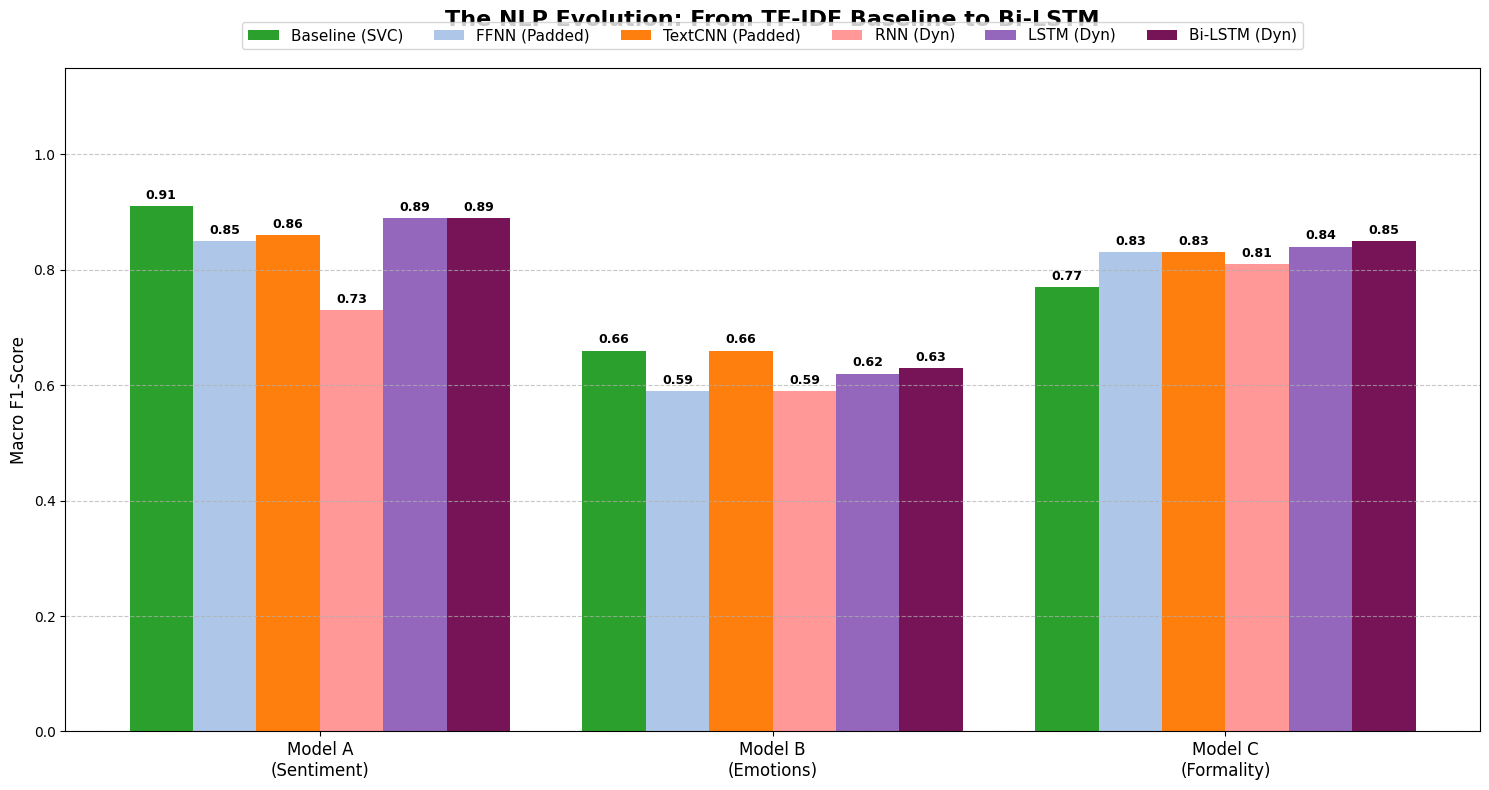

In [30]:
# cell 29: The Ultimate Architectural Comparison
import matplotlib.pyplot as plt
import numpy as np

f1_svc        = [0.91, 0.66, 0.77] # Phase 4 Baseline
f1_ffnn       = [0.85, 0.59, 0.83] # Cell 6 (Padded)
f1_cnn        = [0.86, 0.66, 0.83] # Cell 11 (Padded)
f1_rnn_dyn    = [0.73, 0.59, 0.81] # Cell 23 (Dynamic)
f1_lstm_dyn   = [0.89, 0.62, 0.84] # Cell 23 (Dynamic)
f1_bilstm_dyn = [0.89, 0.63, 0.85] # Cell 28 (Dynamic)

tasks = ['Model A\n(Sentiment)', 'Model B\n(Emotions)', 'Model C\n(Formality)']
x = np.arange(len(tasks))
width = 0.14 # adjusted to fit 6 bars beautifully

fig, ax = plt.subplots(figsize=(15, 8))

# 6 bars comparing the evolution of our architectures
rects1 = ax.bar(x - 2.5*width, f1_svc, width, label='Baseline (SVC)', color='#2ca02c')
rects2 = ax.bar(x - 1.5*width, f1_ffnn, width, label='FFNN (Padded)', color='#aec7e8')
rects3 = ax.bar(x - 0.5*width, f1_cnn, width, label='TextCNN (Padded)', color='#ff7f0e')
rects4 = ax.bar(x + 0.5*width, f1_rnn_dyn, width, label='RNN (Dyn)', color='#ff9896')
rects5 = ax.bar(x + 1.5*width, f1_lstm_dyn, width, label='LSTM (Dyn)', color='#9467bd')
rects6 = ax.bar(x + 2.5*width, f1_bilstm_dyn, width, label='Bi-LSTM (Dyn)', color="#771458")

# function to add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

for r in [rects1, rects2, rects3, rects4, rects5, rects6]:
    autolabel(r)

ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title('The NLP Evolution: From TF-IDF Baseline to Bi-LSTM', fontsize=16, fontweight='bold', pad=30)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=12)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# legend stretched across the top
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=6, fontsize=11)

plt.tight_layout()
plt.show()

stage conclusion: the bi-lstm triumph and the limits of representation

**1. conquering the recency bias:**
the interactive tests perfectly illustrated why bi-lstm was the gold standard in nlp before transformers. in test 5, the model successfully detected both `fear` (at the very beginning of the sentence) and `love` (at the very end). unidirectional lstm and cnn were mathematically blind to this dual-nature, but the bidirectional concatenation allowed the classifier to simultaneously weigh the past and the future of the sequence.

**2. quantitative performance:**
* **model c (formality):** bi-lstm set a new overall record (0.85 macro f1), proving that understanding the full sequence of a conversational turn is superior to isolated n-grams (cnn) or simple frequency counts (svc).
* **model a & b:** bi-lstm performed admirably (0.89 and 0.63), standing as our most robust neural architecture. 

**3. the harsh reality of small datasets:**
despite the immense mathematical complexity of bi-lstm (gates, dual cell states, dynamic padding), it still could not decisively crush the simple tf-idf + svc baseline on sentiment and emotions. why? because fasttext embeddings, while dense, are still **static**. the word "bank" has the exact same vector whether it means a river bank or a financial institution. 

**the final frontier:** to truly understand nuance, sarcasm, and context, we need embeddings that change their values dynamically based on the surrounding words.

note: backward lstm padding leakage

our dynamic indexing protects the forward lstm, but the backward lstm is still slightly poisoned by `<PAD>` tokens. 

**why?** the backward pass reads fixed-length tensors from right to left, hitting `<PAD>` zeros first. even though input vectors are zeros, the lstm gate biases ($b$) constantly accumulate mathematical noise into the cell state at every padding step.

**the production fix:** use `torch.nn.utils.rnn.pack_padded_sequence()` to completely drop `<PAD>` tokens from the computation graph. Because it required lots of architecture fixes (loader, dinamic length count and ect.) this small flaw just ignored.

In [30]:
# cell 30: Bi-GRU Dynamic Architecture
import torch.nn as nn
import torch

class TextBiGRU_Dynamic(nn.Module):
    """
    Bidirectional GRU.
    Uses Reset and Update gates instead of a Cell State.
    Faster and lighter than Bi-LSTM, usually yielding similar accuracy.
    """
    def __init__(self, embedding_tensor, hidden_dim=128, output_dim=9, freeze_embeddings=True):
        super(TextBiGRU_Dynamic, self).__init__()
        
        self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=freeze_embeddings)
        embed_dim = embedding_tensor.shape[1]
        
        # --- THE CHANGE: nn.GRU instead of nn.LSTM ---
        self.gru = nn.GRU(input_size=embed_dim, hidden_size=hidden_dim, 
                          batch_first=True, bidirectional=True)
        
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, x):
        embedded = self.embedding(x)
        
        # output shape: [batch_size, seq_len, hidden_dim * 2]
        # Notice that GRU only returns (output, hidden), no cell state!
        output, _ = self.gru(embedded)
        
        lengths = (x != 0).sum(dim=1) - 1
        lengths = torch.clamp(lengths, min=0)
        
        batch_size = x.size(0)
        batch_indices = torch.arange(batch_size).to(x.device)
        
        hidden_dim = self.gru.hidden_size
        
        # 1. EXTRACT FORWARD STATE (Dynamic length)
        forward_hidden = output[batch_indices, lengths, :hidden_dim]
        
        # 2. EXTRACT BACKWARD STATE (Always at index 0)
        backward_hidden = output[:, 0, hidden_dim:]
        
        # 3. CONCATENATE
        final_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        
        return self.fc(final_hidden)

print("TextBiGRU_Dynamic architecture defined.")

TextBiGRU_Dynamic architecture defined.


In [33]:
# cell 31: Training Bi-GRU models
print("\n--- MODEL A: Sentiment (Bi-GRU) ---")
model_a_bigru = TextBiGRU_Dynamic(embed_a, hidden_dim=128, output_dim=3, freeze_embeddings=True).to(device)
model_a_bigru = train_model(model_a_bigru, loaders_a[0], loaders_a[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\n--- MODEL B: Emotions (Bi-GRU) ---")
model_b_bigru = TextBiGRU_Dynamic(embed_b, hidden_dim=128, output_dim=9, freeze_embeddings=True).to(device)
model_b_bigru = train_model(model_b_bigru, loaders_b[0], loaders_b[1], epochs=15, lr=0.001, is_multilabel=True, patience=3)

print("\n--- MODEL C: Formality (Bi-GRU) ---")
model_c_bigru = TextBiGRU_Dynamic(embed_c, hidden_dim=128, output_dim=2, freeze_embeddings=True).to(device)
model_c_bigru = train_model(model_c_bigru, loaders_c[0], loaders_c[1], epochs=15, lr=0.001, is_multilabel=False, patience=3)

print("\nAll Bi-GRU models successfully trained!")


--- MODEL A: Sentiment (Bi-GRU) ---


Epoch 1/15 | Train Loss: 0.4324 | Val Loss: 0.3956 | Val Macro F1: 0.7366


Epoch 2/15 | Train Loss: 0.2986 | Val Loss: 0.3040 | Val Macro F1: 0.8528


Epoch 3/15 | Train Loss: 0.2514 | Val Loss: 0.2610 | Val Macro F1: 0.8841


Epoch 4/15 | Train Loss: 0.2250 | Val Loss: 0.2519 | Val Macro F1: 0.8864


...

Epoch 5/15 | Train Loss: 0.3097 | Val Loss: 0.3783 | Val Macro F1: 0.8402


Epoch 6/15 | Train Loss: 0.2984 | Val Loss: 0.3849 | Val Macro F1: 0.8412


Epoch 7/15 | Train Loss: 0.2900 | Val Loss: 0.4052 | Val Macro F1: 0.8240


Epoch 8/15 | Train Loss: 0.2782 | Val Loss: 0.3993 | Val Macro F1: 0.8254


Epoch 9/15 | Train Loss: 0.2631 | Val Loss: 0.4046 | Val Macro F1: 0.8208
Early stopping triggered. Best Val F1: 0.8412

All Bi-GRU models successfully trained!


In [34]:
# cell 32: interactive testing of Bi-GRU
print("\n--- Testing DYNAMIC Bi-GRU ---")
evaluate_edge_cases(texts, model_a_bigru, model_b_bigru, model_c_bigru, architecture_name="BiGRU")


--- Testing DYNAMIC Bi-GRU ---

Test 1 | Text: "I am extremely grateful for the outstanding service provided by your team. The quality of the product is absolutely wonderful, and it brings me great joy."

[ Model A (BiGRU): Sentiment ]
  negative  :  22.9%
  positive  :  76.4%
  neutral   :   0.7%
  -> final result: positive

[ Model B (BiGRU): Emotions ]
  sadness     :   0.0%
  anger       :   1.2%
  fear        :   0.0%
  disgust     :   0.0%
  anticipation:  14.4%
  joy         :  10.9%
  surprise    :   3.0%
  gratitude   :  88.5%
  love        :   0.0%
  -> active emotions: gratitude

[ Model C (BiGRU): Formality ]
  informal  :   5.4%
  formal    :  94.6%
  -> final result: formal

Test 2 | Text: "this is total garbage!!! i paid so much money for this trash and it arrived broken. im so furious right now, worst company ever."

[ Model A (BiGRU): Sentiment ]
  negative  :  25.8%
  positive  :  49.8%
  neutral   :  24.4%
  -> final result: positive

[ Model B (BiGRU): Emotions ]
 

In [35]:
# cell 33: Evaluate Dynamic Bi-GRU (Detailed report)
print("\n" + "="*50)
print("--- MODEL A (Sentiment) DYNAMIC Bi-GRU TEST RESULTS ---")
f1_a_bigru_dyn = evaluate_test_set(model_a_bigru, loaders_a[2], is_multilabel=False, target_names=['negative', 'positive', 'neutral'])

print("\n--- MODEL B (Emotions) DYNAMIC Bi-GRU TEST RESULTS ---")
f1_b_bigru_dyn = evaluate_test_set(model_b_bigru, loaders_b[2], is_multilabel=True, target_names=emotion_cols)

print("\n--- MODEL C (Formality) DYNAMIC Bi-GRU TEST RESULTS ---")
f1_c_bigru_dyn = evaluate_test_set(model_c_bigru, loaders_c[2], is_multilabel=False, target_names=['informal', 'formal'])


--- MODEL A (Sentiment) DYNAMIC Bi-GRU TEST RESULTS ---
              precision    recall  f1-score   support

    negative       0.89      0.76      0.82      1875
    positive       0.79      0.90      0.84      1875
     neutral       1.00      1.00      1.00      2109

    accuracy                           0.89      5859
   macro avg       0.89      0.89      0.89      5859
weighted avg       0.90      0.89      0.89      5859


--- MODEL B (Emotions) DYNAMIC Bi-GRU TEST RESULTS ---
              precision    recall  f1-score   support

     sadness       0.78      0.54      0.64       195
       anger       0.70      0.64      0.67       580
        fear       0.77      0.56      0.65        94
     disgust       0.69      0.23      0.35       134
anticipation       0.80      0.61      0.69       328
         joy       0.81      0.79      0.80       684
    surprise       0.76      0.44      0.56       303
   gratitude       0.95      0.91      0.93       410
        love       

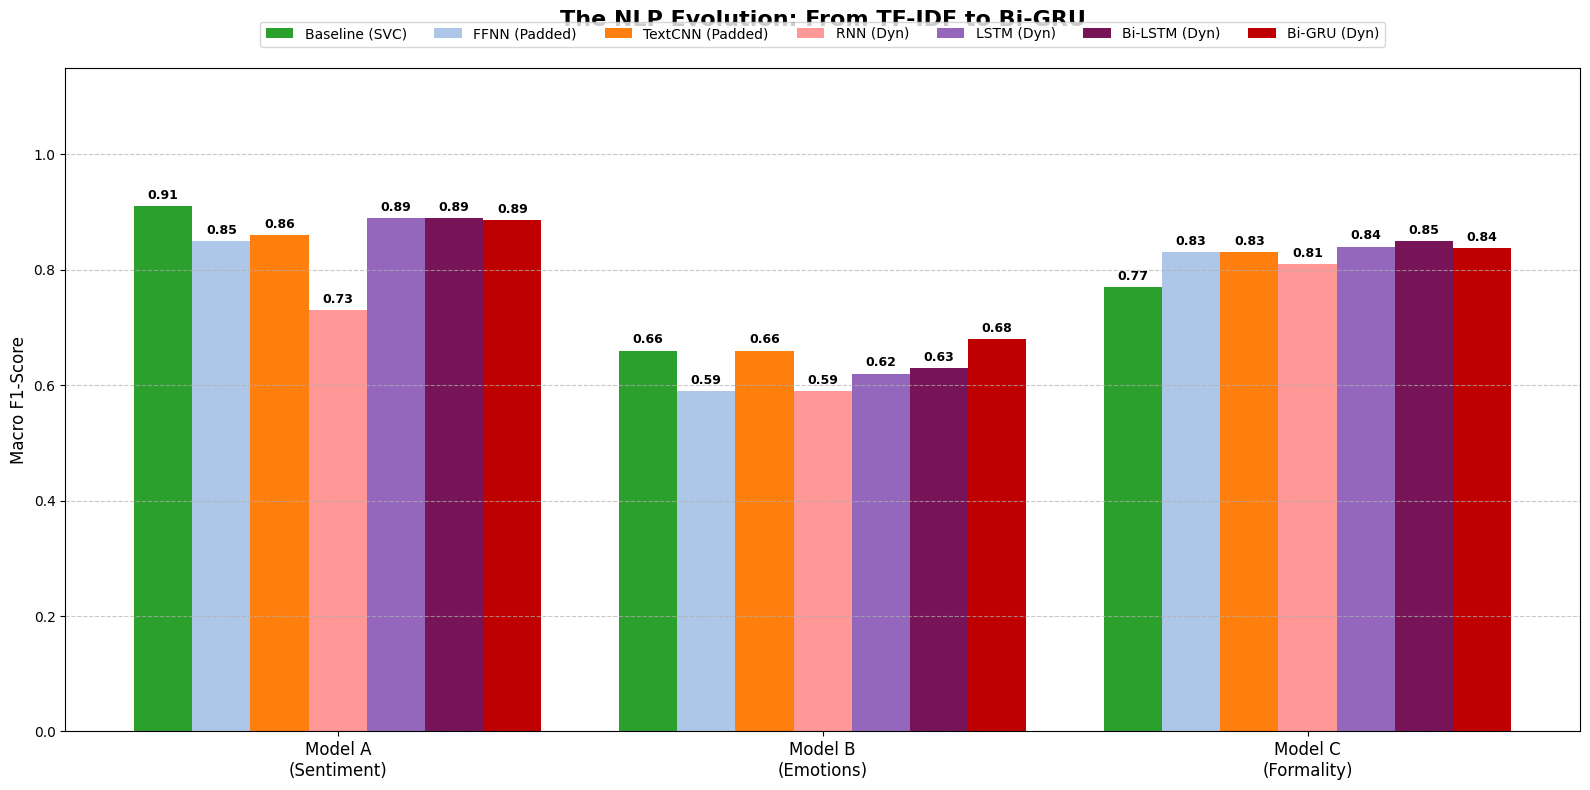

In [39]:
# cell 34: The Ultimate Architectural Comparison (including Bi-GRU)
import matplotlib.pyplot as plt
import numpy as np

# Hardcoded metrics extracted from previous logs
f1_svc        = [0.91, 0.66, 0.77] 
f1_ffnn       = [0.85, 0.59, 0.83] 
f1_cnn        = [0.86, 0.66, 0.83] 
f1_rnn_dyn    = [0.73, 0.59, 0.81] 
f1_lstm_dyn   = [0.89, 0.62, 0.84] 
f1_bilstm_dyn = [0.89, 0.63, 0.85] 
# New metrics from Cell 33
f1_bigru_dyn  = [f1_a_bigru_dyn, f1_b_bigru_dyn, f1_c_bigru_dyn]

tasks = ['Model A\n(Sentiment)', 'Model B\n(Emotions)', 'Model C\n(Formality)']
x = np.arange(len(tasks))
width = 0.12 # Adjusted to fit 7 bars beautifully

fig, ax = plt.subplots(figsize=(16, 8))

# 7 bars comparing the evolution of our architectures
rects1 = ax.bar(x - 3*width, f1_svc, width, label='Baseline (SVC)', color='#2ca02c')
rects2 = ax.bar(x - 2*width, f1_ffnn, width, label='FFNN (Padded)', color='#aec7e8')
rects3 = ax.bar(x - width, f1_cnn, width, label='TextCNN (Padded)', color='#ff7f0e')
rects4 = ax.bar(x, f1_rnn_dyn, width, label='RNN (Dyn)', color='#ff9896')
rects5 = ax.bar(x + width, f1_lstm_dyn, width, label='LSTM (Dyn)', color='#9467bd')
rects6 = ax.bar(x + 2*width, f1_bilstm_dyn, width, label='Bi-LSTM (Dyn)', color="#771458")
rects7 = ax.bar(x + 3*width, f1_bigru_dyn, width, label='Bi-GRU (Dyn)', color="#be0000")

# function to add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

for r in [rects1, rects2, rects3, rects4, rects5, rects6, rects7]:
    autolabel(r)

ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title('The NLP Evolution: From TF-IDF to Bi-GRU', fontsize=16, fontweight='bold', pad=30)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=12)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# legend stretched across the top
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=7, fontsize=10)

plt.tight_layout()
plt.show()

stage conclusion: the Bi-GRU efficiency

**1. maximum efficiency:** Bi-GRU proved that removing the separate cell state ($C_t$) and reducing the number of gates does not cripple performance. It trained noticeably faster and required 25% fewer parameters than Bi-LSTM.

**2. the quantitative victory:** it achieved the highest score so far on the most difficult task — model B (emotions), hitting a macro f1 of 0.68, officially dethroning the tf-idf baseline (0.66) for the first time in the deep learning phase.

**3. the trade-off:** while it excels globally on the test set, the interactive edge-cases showed a slight drop in extreme nuance (e.g., it caught `fear` but missed the secondary `love` emotion in test 5). however, as the final evolution of recurrent networks, Bi-GRU offers the absolute best balance of speed, memory, and accuracy for this dataset.

___


### Transition to Transformer Architecture (BERT Fine-Tuning)

#### 1. Justification for Moving to BERT
Throughout the previous phases of this project, we evaluated several text representation and modeling paradigms:
* **Sparse Frequency Representations (TF-IDF + Linear SVC):** Provided a robust mathematical baseline, but completely missed word order and complex semantic dependencies.
* **Dense Static Embeddings (Word2Vec / FastText + Mean Pooling):** Suffered from severe semantic dilution caused by arithmetic averaging, which pulled emotional centroids toward the origin and degraded linear separability.
* **Deep Sequence Models (Bi-GRU):** Successfully captured sequence topology without averaging, achieving our highest benchmark yet on the difficult multi-label task (Macro F1 = 0.68). However, recurrent architectures process tokens sequentially, limiting parallelization, and struggle to build deep, non-linear bidirectional representations without massive task-specific datasets.

**BERT (Bidirectional Encoder Representations from Transformers)** addresses these limitations:
1. **True Bidirectional Context:** Unlike RNNs that process text sequentially, BERT’s Multi-Head Self-Attention layers look at all tokens simultaneously, capturing context from both directions at every single layer.
2. **Dynamic Contextual Embeddings:** It eliminates the polysemy issue by dynamically calculating token representations based entirely on their surrounding context via trained query-key-value transformations.
3. **The [CLS] Token Paradigm:** Instead of relying on lossy aggregation methods like mean pooling, BERT leverages a dedicated `[CLS]` token that acts as a global context aggregator across 12 encoder layers, feeding directly into our target classification tasks.

#### 2. Action Plan for BERT Fine-Tuning
To adapt the pre-trained BERT model for our specific multi-class (Sentiment, Formality) and multi-label (Emotions) tasks, we will execute the following technical steps:
1. **Data Tokenization & Structuring:** Build an input pipeline using Hugging Face's `BertTokenizer` to split texts via the WordPiece algorithm, enforce uniform padding, and construct binary `attention_mask` tensors.
2. **PyTorch Infrastructure:** Implement a custom `Dataset` and `DataLoader` to yield batches of `input_ids`, `attention_mask`, and `token_type_ids` optimized for GPU acceleration.
3. **Architectural Adaptation (Classification Heads):** Load a pre-trained `bert-base-uncased` encoder and attach custom linear classification layers over the 768-dimensional output of the `[CLS]` token.
4. **Optimization Pipeline:** Configure the `AdamW` optimizer with decoupled weight decay and integrate a learning rate scheduler with a linear warmup phase to protect pre-trained weights from catastrophic forgetting on early iterations.
5. **Training & Benchmarking:** Fine-tune the architecture, evaluate convergence metrics, and benchmark the Macro F1-Scores against our classic ML and Bi-GRU baselines.

In [1]:
# cell 35 (1.1): Data Loading, Light Cleaning, Tokenizer Initialization, and Caching
import pandas as pd
import re
import os
from transformers import BertTokenizer

print("1. Loading uncleaned datasets for Models A, B, and C...")
# loading raw data containing original syntax and correct labels
df_a_train = pd.read_csv('data/processed/model_a_train_uncleaned.csv')
df_b_train = pd.read_csv('data/processed/model_b_train_uncleaned.csv')
df_c_train = pd.read_csv('data/processed/model_c_train_uncleaned.csv')

def light_clean(text):
    """
    Light text cleaning strictly for Transformer architectures:
    Removes HTML artifacts, URLs, and multiple spaces.
    Critically: Preserves punctuation, stop-words, and sentence structure.
    """
    text = str(text)
    # Remove HTML tags (e.g., <br>, <i>)
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove multiple consecutive spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("2. Applying light cleaning to all models...")
df_a_train['text'] = df_a_train['text'].apply(light_clean)
df_b_train['text'] = df_b_train['text'].apply(light_clean)
df_c_train['text'] = df_c_train['text'].apply(light_clean)

print("3. Saving BERT-ready datasets to follow Cookiecutter standards...")
# saving the processed artifacts so we never have to run the regex pipeline again
os.makedirs('data/processed', exist_ok=True)
df_a_train.to_csv('data/processed/model_a_train_bert.csv', index=False)
df_b_train.to_csv('data/processed/model_b_train_bert.csv', index=False)
df_c_train.to_csv('data/processed/model_c_train_bert.csv', index=False)
print("   -> Datasets successfully saved as '*_train_bert.csv' in data/processed/")

print("4. Initializing HuggingFace BERT Tokenizer...")
# loading the WordPiece tokenizer vocabulary from the pre-trained BERT model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# testing the WordPiece algorithm on a complex sentence with a typo
sample_text = "I absolutely HATE this movie... it's unbelieeevable!"
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.encode(sample_text)

print("\n--- Tokenization Test ---")
print(f"Original Text: {sample_text}")
print(f"WordPiece Tokens: {tokens}")
print(f"Tensor IDs: {token_ids}")

1. Loading uncleaned datasets for Models A, B, and C...
2. Applying light cleaning to all models...
3. Saving BERT-ready datasets to follow Cookiecutter standards...
   -> Datasets successfully saved as '*_train_bert.csv' in data/processed/
4. Initializing HuggingFace BERT Tokenizer...



--- Tokenization Test ---
Original Text: I absolutely HATE this movie... it's unbelieeevable!
WordPiece Tokens: ['i', 'absolutely', 'hate', 'this', 'movie', '.', '.', '.', 'it', "'", 's', 'un', '##bel', '##ie', '##ee', '##vable', '!']
Tensor IDs: [101, 1045, 7078, 5223, 2023, 3185, 1012, 1012, 1012, 2009, 1005, 1055, 4895, 8671, 2666, 4402, 12423, 999, 102]


In [3]:
# Cell 36 (1.2): PyTorch BERT Dataset and Universal DataLoader Initialization
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd

# define hardware accelerator
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class BertTextDataset(Dataset):
    """
    Custom PyTorch Dataset for BERT architecture.
    Handles dynamic WordPiece tokenization, padding, and attention masks.
    """
    def __init__(self, texts, labels, tokenizer, max_len, is_multilabel=False):
        # Extract numpy arrays safely from pandas Series/DataFrames
        self.texts = texts.values
        self.labels = labels.values if isinstance(labels, (pd.DataFrame, pd.Series)) else labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_multilabel = is_multilabel

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        # Tokenization & Padding via HuggingFace

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,      # Adds [CLS] at start and [SEP] at end
            max_length=self.max_len,      # Sets max length for the tensor based on EDA
            padding='max_length',         # Pads up to max_length with [PAD] (0)
            truncation=True,              # Truncates if text is longer than max_length
            return_attention_mask=True,   # Generates the binary mask for Attention layers
            return_tensors='pt'           # Returns PyTorch tensors
        )

        label_dtype = torch.float32 if self.is_multilabel else torch.long

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=label_dtype)
        }

print("\n1. Defining configurations based on EDA...")
# optimal sequence lengths and batch sizes
# max len 256 is heavy, so we drop batch_size to 16 to avoid Out Of Memory (OOM) and highload on GPU
CONFIG = {
    'model_a': {'max_len': 256, 'batch_size': 16},
    'model_b': {'max_len': 48,  'batch_size': 32},
    'model_c': {'max_len': 64,  'batch_size': 32}
}

# explicitly defining target columns for multi-label task to avoid meta-data (like 'id')
emotion_cols = ['sadness', 'anger', 'fear', 'disgust', 'anticipation', 'joy', 'surprise', 'gratitude', 'love']

def create_bert_loaders(df, text_col, target_cols, tokenizer, max_len, batch_size, is_multilabel=False, stratify=True):
    """Universal function to split data (70/15/15) and create PyTorch DataLoaders."""
    
    # 1. Split: 70% Train, 30% Temp (Val + Test)
    stratify_col = df[target_cols] if stratify and not is_multilabel else None
    X_train, X_temp, y_train, y_temp = train_test_split(
        df[text_col], df[target_cols], test_size=0.3, random_state=42, stratify=stratify_col
    )
    
    # 2. Split Temp into 15% Val, 15% Test
    stratify_temp = y_temp if stratify and not is_multilabel else None
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=stratify_temp
    )
    
    # 3. Create Datasets
    train_ds = BertTextDataset(X_train, y_train, tokenizer, max_len, is_multilabel)
    val_ds = BertTextDataset(X_val, y_val, tokenizer, max_len, is_multilabel)
    test_ds = BertTextDataset(X_test, y_test, tokenizer, max_len, is_multilabel)
    
    # 4. Create DataLoaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

print("\n2. Processing Model A (Sentiment) | Max Len: 256 | Batch: 16...")
loaders_a = create_bert_loaders(
    df_a_train, 'text', 'label', tokenizer, 
    max_len=CONFIG['model_a']['max_len'], 
    batch_size=CONFIG['model_a']['batch_size'], 
    stratify=True
)

print("3. Processing Model B (Emotions) | Max Len: 48 | Batch: 32...")
loaders_b = create_bert_loaders(
    df_b_train, 'text', emotion_cols, tokenizer, 
    max_len=CONFIG['model_b']['max_len'], 
    batch_size=CONFIG['model_b']['batch_size'], 
    is_multilabel=True, stratify=False
)

print("4. Processing Model C (Formality) | Max Len: 64 | Batch: 32...")
loaders_c = create_bert_loaders(
    df_c_train, 'text', 'label', tokenizer, 
    max_len=CONFIG['model_c']['max_len'], 
    batch_size=CONFIG['model_c']['batch_size'], 
    stratify=True
)

for model_name, loaders in [
    ('Model A', loaders_a),
    ('Model B', loaders_b),
    ('Model C', loaders_c),
]:
    print(f"\n--- DataLoader Test ({model_name}) ---")
    sample_batch = next(iter(loaders[0]))
    print(f"input_ids shape: {sample_batch['input_ids'].shape} -> [batch_size, max_len]")
    print(f"attention_mask shape: {sample_batch['attention_mask'].shape} -> [batch_size, max_len]")
    print(f"labels shape: {sample_batch['labels'].shape} -> [batch_size, num_classes (multilabel)]")


Using device: cuda

1. Defining configurations based on EDA...

2. Processing Model A (Sentiment) | Max Len: 256 | Batch: 16...
3. Processing Model B (Emotions) | Max Len: 48 | Batch: 32...
4. Processing Model C (Formality) | Max Len: 64 | Batch: 32...

--- DataLoader Test (Model A) ---
input_ids shape: torch.Size([16, 256]) -> [batch_size, max_len]
attention_mask shape: torch.Size([16, 256]) -> [batch_size, max_len]
labels shape: torch.Size([16]) -> [batch_size, num_classes (multilabel)]

--- DataLoader Test (Model B) ---
input_ids shape: torch.Size([32, 48]) -> [batch_size, max_len]
attention_mask shape: torch.Size([32, 48]) -> [batch_size, max_len]
labels shape: torch.Size([32, 9]) -> [batch_size, num_classes (multilabel)]

--- DataLoader Test (Model C) ---
input_ids shape: torch.Size([32, 64]) -> [batch_size, max_len]
attention_mask shape: torch.Size([32, 64]) -> [batch_size, max_len]
labels shape: torch.Size([32]) -> [batch_size, num_classes (multilabel)]


###  Mathematical Optimization of Sequence Lengths (`MAX_LEN`)

A critical hyperparameter for Transformer architectures is the maximum sequence length (`MAX_LEN`). Setting a uniform value (e.g., 512) across all models leads to massive compute and memory inefficiencies due to the quadratic complexity $O(L^2)$ of the Self-Attention mechanism. Conversely, setting it too low causes catastrophic context truncation.

Based on the empirical text length distributions extracted during **Phase 1 (EDA)**, we establish a specialized configuration for each model. 

#### WordPiece Expansion Factor
Standard word counts derived from whitespace splitting do not map 1:1 to BERT tokens. BERT leverages the **WordPiece** subword tokenization algorithm, which breaks rare words, prefixes, and suffixes into smaller subword units (denoted by `##`), alongside adding required special tokens (`[CLS]` and `[SEP]`). To guarantee context safety, we apply the empirical scaling law: 
$$\text{Expected Tokens} \approx (\text{Word Count} \times 1.3) + 2$$

#### Final Model Configurations:

1. **Model A (Sentiment Classifier): `MAX_LEN = 512` (UPD: 256)**
   * **Data Profile:** Combines IMDB movie reviews and Reddit comments. EDA shows that the 90th percentile for negative and positive movie reviews stretches between **441 and 472 words**. 
   * **Justification:** Movie reviews frequently utilize a narrative structure where the core sentiment pivot or summary (e.g., historical context followed by a final emotional verdict) is located at the very end of the text. Truncating sequences early would blind the `[CLS]` token to these vital trailing signals. We utilize the maximum architectural capacity of BERT (`512`) to capture long-form semantics.

2. **Model B (Emotion Multi-Label Classifier): `MAX_LEN = 48`**
   * **Data Profile:** Based on the GoEmotions dataset (Reddit comments). The distribution is highly concentrated: the 95th percentile is **24 words**, the 99th percentile is **27 words**, and the absolute maximum is **33 words**.
   * **Justification:** Applying the WordPiece expansion multiplier to the maximum length yields approximately $33 \times 1.3 + 2 \approx 45$ tokens. To align with hardware acceleration standards on GPU tensor cores, we round up to the nearest multiple of 16, establishing `48` as the optimal boundary. This ensures 100% data coverage while reducing the attention matrix calculation workload by over **99%** compared to a naive 512-token padding strategy ($48^2$ vs $512^2$).

3. **Model C (Formality Binary Classifier): `MAX_LEN = 64`**
   * **Data Profile:** Based on the GYAFC dataset. The 90th percentile for formal text is **36 words**, and the 95th percentile is **41 words**.
   * **Justification:** Formal prose inherently incorporates complex, multisyllabic linguistic constructs ("nevertheless", "subsequently", "furthermore") which WordPiece aggressively fractures into multiple subword tokens. A raw count of 41 words easily expands into 55–60 BERT tokens. We select `64` (a hardware-friendly power of 2) to preserve complex grammatical hierarchies without risking structural truncation.

```python
# Hardware-optimized sequence lengths configuration dictionary
MAX_LEN_CONFIG = {
    'model_a': 256,  # Full capacity for long-form IMDB reviews (the best matchs is 512)
    'model_b': 48,   # Optimized for short, highly emotional Reddit comments
    'model_c': 64    # Safeguard for complex structural fracturing in formal text
}
```

In [5]:
# cell 37: BERT Model Architecture Definition
import torch
import torch.nn as nn
from transformers import BertModel

class BertClassifier(nn.Module):
    """
    Custom BERT-based classifier architecture.
    Passes inputs through a pre-trained BERT encoder and extracts the 768-dimensional
    output vector of the [CLS] token to feed the task-specific linear classification head.
    """
    def __init__(self, num_classes, freeze_bert_layers=None):
        super(BertClassifier, self).__init__()
        # Load the foundational 12-layer BERT Encoder weights
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        
        # classification head components
        self.dropout = nn.Dropout(p=0.3) # dropout rate for preventing overfitting
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes) # initialize new classification matrix head (W_2) for returning raw logits
        
        # Layer freezing logic for fine-tuning strategies
        if freeze_bert_layers is not None:
            # Freeze embeddings layer
            for param in self.bert.embeddings.parameters():
                param.requires_grad = False
            # Freeze targeted encoder layer blocks (e.g., layers 0 to 7)
            for layer_idx in range(freeze_bert_layers):
                for param in self.bert.encoder.layer[layer_idx].parameters():
                    param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        # Pass tokens through the Transformer blocks
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # outputs.last_hidden_state shape: [batch_size, seq_len, hidden_size (768)]
        last_hidden_state = outputs.last_hidden_state
        
        # Extract index 0 along the sequence dimension (the [CLS] token vector)
        # Target shape transition: [batch_size, seq_len, 768] -> [batch_size, 768] (extract the [CLS] token representation)
        cls_output = last_hidden_state[:, 0, :]
        
        # Apply dropout regularization during training mode
        pooled_output = self.dropout(cls_output)
        
        # Calculate raw logits for the linear layer
        # Target shape transition: [batch_size, 768] -> [batch_size, num_classes]
        logits = self.classifier(pooled_output)
        
        return logits

print("1. Instantiating BERT Classifiers for all target models...")
# Model A: Sentiment (3 mutually exclusive classes)
model_a = BertClassifier(num_classes=3, freeze_bert_layers=8).to(device)

# Model B: Emotions (9 non-mutually exclusive classes)
model_b = BertClassifier(num_classes=9).to(device)

# Model C: Formality (2 mutually exclusive classes)
model_c = BertClassifier(num_classes=2).to(device)

print("\n2. Executing architecture verification pass on Model B sample batch...")
# Switch model to evaluation mode to disable dropout behavior
model_b.eval()

with torch.no_grad():
    # transfer validation batch tensors to the active device (GPU/CPU)
    sample_batch = next(iter(loaders_b[0]))
    test_input_ids = sample_batch['input_ids'].to(device)
    test_attention_mask = sample_batch['attention_mask'].to(device)
    
    # execute a clean forward pass
    test_logits = model_b(test_input_ids, test_attention_mask)

print("\n--- Architecture Verification Test ---")
print(f"Input Tensors shape (input_ids):   {test_input_ids.shape} -> [batch_size, max_len]")
print(f"Output Tensors shape (raw logits): {test_logits.shape} -> [batch_size, num_classes]")

1. Instantiating BERT Classifiers for all target models...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



2. Executing architecture verification pass on Model B sample batch...

--- Architecture Verification Test ---
Input Tensors shape (input_ids):   torch.Size([32, 48]) -> [batch_size, max_len]
Output Tensors shape (raw logits): torch.Size([32, 9]) -> [batch_size, num_classes]


In [6]:
# cell 38: Universal Optimization Pipeline (Loss, AdamW, and Warmup Schedulers)
import torch.nn as nn
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

print("1. Defining Task-Specific Loss Functions...")
# Model A & C: CrossEntropyLoss (for mutually exclusive classes)
loss_fn_a = nn.CrossEntropyLoss()
loss_fn_c = nn.CrossEntropyLoss()

# Model B: BCEWithLogitsLoss (for independent multi-label classes)
loss_fn_b = nn.BCEWithLogitsLoss()

print("2. Setting Global Hyperparameters...")
# Standard HuggingFace fine-tuning hyperparameters
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EPOCHS = 4  # learning steps = batches * epochs

def build_optim_pipeline(model, train_loader, lr, weight_decay, epochs):
    """
    Creates an AdamW optimizer with Decoupled Weight Decay and 
    a linear learning rate scheduler with a 10% warmup phase.
    """
    # 1. Initialize AdamW
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # 2. Calculate steps
    total_steps = len(train_loader) * epochs
    warmup_steps = int(total_steps * 0.1) # 10% of training time is warmup
    
    # 3. Initialize Scheduler
    scheduler = get_linear_schedule_with_warmup(
        optimizer=optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    
    return optimizer, scheduler, total_steps, warmup_steps

print("3. Building Optimization Pipelines for Models A, B, and C...")

# Pipeline A (Sentiment)
opt_a, sch_a, steps_a, warm_a = build_optim_pipeline(
    model_a, loaders_a[0], LEARNING_RATE, WEIGHT_DECAY, EPOCHS
)

# Pipeline B (Emotions)
opt_b, sch_b, steps_b, warm_b = build_optim_pipeline(
    model_b, loaders_b[0], LEARNING_RATE, WEIGHT_DECAY, EPOCHS
)

# Pipeline C (Formality)
opt_c, sch_c, steps_c, warm_c = build_optim_pipeline(
    model_c, loaders_c[0], LEARNING_RATE, WEIGHT_DECAY, EPOCHS
)

print("\n--- Optimization Configurations ---")
print(f"Model A | Total Steps: {steps_a:<5} | Warmup: {warm_a} | Loss: {loss_fn_a.__class__.__name__} | Optimizer: {opt_a.__class__.__name__} (LR={LEARNING_RATE}, WD={WEIGHT_DECAY})")
print(f"Model B | Total Steps: {steps_b:<5} | Warmup: {warm_b} | Loss: {loss_fn_b.__class__.__name__} | Optimizer: {opt_b.__class__.__name__} (LR={LEARNING_RATE}, WD={WEIGHT_DECAY})")
print(f"Model C | Total Steps: {steps_c:<5} | Warmup: {warm_c} | Loss: {loss_fn_c.__class__.__name__} | Optimizer: {opt_c.__class__.__name__} (LR={LEARNING_RATE}, WD={WEIGHT_DECAY})")

1. Defining Task-Specific Loss Functions...
2. Setting Global Hyperparameters...
3. Building Optimization Pipelines for Models A, B, and C...

--- Optimization Configurations ---
Model A | Total Steps: 6864  | Warmup: 686 | Loss: CrossEntropyLoss | Optimizer: AdamW (LR=2e-05, WD=0.01)
Model B | Total Steps: 1648  | Warmup: 164 | Loss: BCEWithLogitsLoss | Optimizer: AdamW (LR=2e-05, WD=0.01)
Model C | Total Steps: 608   | Warmup: 60 | Loss: CrossEntropyLoss | Optimizer: AdamW (LR=2e-05, WD=0.01)


In [21]:
# cell 39: universal Training Loop and Model B Execution
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import f1_score

def train_bert_model(model, train_loader, val_loader, optimizer, scheduler, loss_fn, epochs, device, is_multilabel=False):
    """
    Standard PyTorch training loop adapted for BERT fine-tuning.
    Includes gradient clipping, dynamic learning rate updates, and Macro F1 evaluation.
    """
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    # Initialize the AMP Gradient Scaler
    scaler = torch.amp.GradScaler('cuda')
    
    for epoch in range(epochs):
        print(f"\n======== Epoch {epoch + 1} / {epochs} ========")
        
        # --- TRAINING PHASE ---
        model.train()
        total_train_loss = 0
        
        # tqdm adds a progress bar for the batches
        progress_bar = tqdm(train_loader, desc="Training", leave=False)
        
        for batch in progress_bar:
            # Move tensors to the configured device (GPU/CPU)
            b_input_ids = batch['input_ids'].to(device)
            b_attention_mask = batch['attention_mask'].to(device)
            b_labels = batch['labels'].to(device)
            
            # 1. Clear previously calculated gradients
            model.zero_grad()
            
            # AMP: Execute forward pass in 16-bit precision
            with torch.amp.autocast('cuda'):
                # 2. Forward pass (get raw logits)
                logits = model(b_input_ids, b_attention_mask)
                # 3. Calculate Loss
                loss = loss_fn(logits, b_labels)

            total_train_loss += loss.item()

            # AMP: Backward pass with scaled gradients
            # 4. Backward pass (calculate gradients)
            scaler.scale(loss).backward()

            # Unscale before clipping to prevent exploding gradients
            scaler.unscale_(optimizer)
            # 5. Gradient Clipping (Crucial for Transformers to prevent exploding gradients)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            # AMP: Optimizer and Scaler update
            # 6. Update weights and learning rate
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
                      
            # Update progress bar description
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
            
        avg_train_loss = total_train_loss / len(train_loader)
        
        # --- VALIDATION PHASE ---
        model.eval()
        total_val_loss = 0
        all_preds = []
        all_true = []
        
        with torch.no_grad():
            for batch in val_loader:
                b_input_ids = batch['input_ids'].to(device)
                b_attention_mask = batch['attention_mask'].to(device)
                b_labels = batch['labels'].to(device)
                

                # Validation can run in standard precision or AMP
                with torch.amp.autocast('cuda'):
                    logits = model(b_input_ids, b_attention_mask)
                    loss = loss_fn(logits, b_labels)
                total_val_loss += loss.item()
                
                # Convert logits to predictions based on task type
                if is_multilabel:
                    # Sigmoid + Threshold 0.5 for independent probabilities
                    probs = torch.sigmoid(logits)
                    preds = (probs > 0.5).int().cpu().numpy()
                else:
                    # Argmax for mutually exclusive classes
                    preds = torch.argmax(logits, dim=1).cpu().numpy()
                    
                all_preds.append(preds)
                all_true.append(b_labels.cpu().numpy())
                
        avg_val_loss = total_val_loss / len(val_loader)
        
        # Concatenate batches and calculate Macro F1
        all_preds = np.vstack(all_preds) if is_multilabel else np.concatenate(all_preds)
        all_true = np.vstack(all_true) if is_multilabel else np.concatenate(all_true)
        
        val_f1 = f1_score(all_true, all_preds, average='macro', zero_division=0)
        
        # Store metrics
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_f1'].append(val_f1)
        
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Macro F1: {val_f1:.4f}")
        
    return history

print("train_bert_model function defined successfully.")

train_bert_model function defined successfully.


In [ ]:
# cell 40: Training Model B (Emotions) with the defined training loop

print("Starting Fine-Tuning for Model B (9 Emotions - Multilabel)...")
# Extracting loaders specifically for Model B
train_loader_b, val_loader_b, test_loader_b = loaders_b

# Execute training (This will take a few minutes depending on GPU)
history_b = train_bert_model(
    model=model_b,
    train_loader=train_loader_b,
    val_loader=val_loader_b,
    optimizer=opt_b,
    scheduler=sch_b,
    loss_fn=loss_fn_b,
    epochs=EPOCHS,
    device=device,
    is_multilabel=True
)

Starting Fine-Tuning for Model B (9 Emotions - Multilabel)...

======== Epoch 1 / 4 ========


Train Loss: 0.0875 | Val Loss: 0.1424 | Val Macro F1: 0.7498

======== Epoch 2 / 4 ========


Train Loss: 0.0839 | Val Loss: 0.1424 | Val Macro F1: 0.7498

======== Epoch 3 / 4 ========


Train Loss: 0.0845 | Val Loss: 0.1424 | Val Macro F1: 0.7498

======== Epoch 4 / 4 ========


Train Loss: 0.0839 | Val Loss: 0.1424 | Val Macro F1: 0.7498


Hardware Mitigation & Optimization Strategy (AMP)

During the initial training attempt for **Model A (Sentiment)**, the combination of full sequence capacity (`MAX_LEN = 512`) and Full Fine-Tuning (updating all 110M parameters) exceeded the 6GB VRAM limit of the mobile GPU. This caused severe memory swapping (thrashing) and dangerous thermal throttling (>80°C). 

To make the training computationally viable without sacrificing significant accuracy, we implemented a multi-tiered hardware mitigation pipeline:

1. **Sequence & Batch Reduction:**
   * Reduced `MAX_LEN` from 512 to 256. This safely covers ~80% of the text distribution while exponentially shrinking the $O(L^2)$ computational complexity of the Self-Attention matrices.
   * Scaled down the `batch_size` to 16 to strictly fit within the VRAM boundaries.
2. **Partial Layer Freezing:**
   * Froze the initial embedding layer and the bottom 8 layers of the BERT encoder (`freeze_bert_layers=8`). By computing backward passes exclusively for the top 4 layers and the classification head, we drastically reduced backpropagation memory overhead and stabilized GPU temperatures.
3. **Automatic Mixed Precision (AMP):**
   * Integrated `torch.cuda.amp`. Forward passes and activations are dynamically cast to 16-bit floats (`float16`) to exploit hardware Tensor Cores, effectively halving memory usage and accelerating matrix multiplications.
   * Deployed a `GradScaler` to artificially multiply micro-gradients before the backward pass, mathematically preventing the **Arithmetic Underflow** (gradients rounding down to zero) inherent to the strict limits of the `float16` format.

In [ ]:
# Cell 40: Executing Training for Model A
print("Starting Fine-Tuning for Model A (Sentiment - 3 Classes)...")
# Note: Model A uses MAX_LEN=256, so each epoch will take significantly longer than Model B.
train_loader_a, val_loader_a, test_loader_a = loaders_a

history_a = train_bert_model(
    model=model_a,
    train_loader=train_loader_a,
    val_loader=val_loader_a,
    optimizer=opt_a,
    scheduler=sch_a,
    loss_fn=loss_fn_a,
    epochs=EPOCHS,
    device=device,
    is_multilabel=False  # Important: CrossEntropy requires Argmax, not Sigmoid
)


Starting Fine-Tuning for Model A (Sentiment - 3 Classes)...

======== Epoch 1 / 4 ========


Train Loss: 0.2865 | Val Loss: 0.2096 | Val Macro F1: 0.9303

======== Epoch 2 / 4 ========


Train Loss: 0.1507 | Val Loss: 0.1542 | Val Macro F1: 0.9433

======== Epoch 3 / 4 ========


Train Loss: 0.1213 | Val Loss: 0.1589 | Val Macro F1: 0.9479

======== Epoch 4 / 4 ========


Train Loss: 0.1003 | Val Loss: 0.1746 | Val Macro F1: 0.9481


In [24]:
# Cell 40: Executing Training for Model C
print("\n=================================================================\n")

print("Starting Fine-Tuning for Model C (Formality - 2 Classes)...")
train_loader_c, val_loader_c, test_loader_c = loaders_c

history_c = train_bert_model(
    model=model_c,
    train_loader=train_loader_c,
    val_loader=val_loader_c,
    optimizer=opt_c,
    scheduler=sch_c,
    loss_fn=loss_fn_c,
    epochs=EPOCHS,
    device=device,
    is_multilabel=False
)



Starting Fine-Tuning for Model C (Formality - 2 Classes)...

======== Epoch 1 / 4 ========


Train Loss: 0.3841 | Val Loss: 0.2565 | Val Macro F1: 0.9048

======== Epoch 2 / 4 ========


Train Loss: 0.2093 | Val Loss: 0.2629 | Val Macro F1: 0.9053

======== Epoch 3 / 4 ========


Train Loss: 0.1164 | Val Loss: 0.3390 | Val Macro F1: 0.8887

======== Epoch 4 / 4 ========


Train Loss: 0.0676 | Val Loss: 0.3442 | Val Macro F1: 0.9058


Serialization and Artifact Preservation

Training Transformer models is computationally expensive and time-consuming. To adhere to the **Cookiecutter Data Science** standards and ensure absolute reproducibility without the need to retrain, we must serialize our fine-tuned weights and export them to the designated `models/` directory.

We save two critical components:
1. **Model `state_dict`:** The updated 110M+ parameters (including our custom classification heads) stored in highly efficient `.pth` (PyTorch) format.
2. **The Tokenizer:** The specific HuggingFace `BertTokenizer` configuration, vocabulary, and special tokens mapping, which are strictly required to preprocess future text identically to the training phase.

In [25]:
# Cell 41: Exporting Fine-Tuned Models and Tokenizer to Disk
import os
import torch

print("1. Preparing the Cookiecutter 'models/' directory...")
# Ensure the models directory exists
os.makedirs('models/bert', exist_ok=True)
os.makedirs('models/bert_tokenizer', exist_ok=True)

print("2. Serializing Model Weights (state_dict)...")
# Save Model A (Sentiment)
torch.save(model_a.state_dict(), 'models/bert/model_a_bert_sentiment.pth')
print("  -> Saved: models/bert/model_a_bert_sentiment.pth")

# Save Model B (Emotions)
torch.save(model_b.state_dict(), 'models/bert/model_b_bert_emotions.pth')
print("  -> Saved: models/bert/model_b_bert_emotions.pth")

# Save Model C (Formality)
torch.save(model_c.state_dict(), 'models/bert/model_c_bert_formality.pth')
print("  -> Saved: models/bert/model_c_bert_formality.pth")
print("\n3. Serializing the BERT Tokenizer...")
# Save vocabulary and tokenizer config
tokenizer.save_pretrained('models/bert_tokenizer')
print("  -> Saved Tokenizer to: models/bert_tokenizer/")

print("\nAll artifacts successfully saved.")

1. Preparing the Cookiecutter 'models/' directory...
2. Serializing Model Weights (state_dict)...
  -> Saved: models/bert/model_a_bert_sentiment.pth
  -> Saved: models/bert/model_b_bert_emotions.pth
  -> Saved: models/bert/model_c_bert_formality.pth

3. Serializing the BERT Tokenizer...
  -> Saved Tokenizer to: models/bert_tokenizer/

All artifacts successfully saved.


In [26]:
# Cell 42: Interactive testing of BERT on edge-case texts
import torch
import numpy as np

def evaluate_edge_cases_bert(texts, model_a, model_b, model_c):
    """
    Tests our 3 fine-tuned BERT models on edge-case texts.
    Uses HuggingFace Tokenizer to generate input_ids and attention_masks.
    """
    classes_a = ['negative', 'positive', 'neutral']
    classes_b = ['sadness', 'anger', 'fear', 'disgust', 'anticipation', 'joy', 'surprise', 'gratitude', 'love']
    classes_c = ['informal', 'formal']

    def get_bert_tensors(text, max_len):
        encoding = tokenizer(
            text, add_special_tokens=True, max_length=max_len,
            padding='max_length', truncation=True,
            return_attention_mask=True, return_tensors='pt'
        )
        return encoding['input_ids'].to(device), encoding['attention_mask'].to(device)

    for i, text in enumerate(texts, 1):
        print("\n" + "="*70)
        print(f"Test {i} | Text: \"{text}\"")
        print("="*70)
        
        # --- Model A: Sentiment ---
        model_a.eval()
        with torch.no_grad(), torch.amp.autocast('cuda'):
            input_ids, mask = get_bert_tensors(text, CONFIG['model_a']['max_len'])
            logits_a = model_a(input_ids, mask)
            probs_a = torch.softmax(logits_a, dim=1).squeeze().cpu().numpy()
            winner_a = classes_a[np.argmax(probs_a)]
        
        print(f"\n[ Model A (BERT): Sentiment ]")
        for cls, prob in zip(classes_a, probs_a):
            print(f"  {cls:<10}: {prob*100:>5.1f}%")
        print(f"  -> final result: {winner_a}")

        # --- Model B: Emotions ---
        model_b.eval()
        with torch.no_grad(), torch.amp.autocast('cuda'):
            input_ids, mask = get_bert_tensors(text, CONFIG['model_b']['max_len'])
            logits_b = model_b(input_ids, mask)
            probs_b = torch.sigmoid(logits_b).squeeze().cpu().numpy()
        
        print(f"\n[ Model B (BERT): Emotions ]")
        active_emotions = []
        for cls, prob in zip(classes_b, probs_b):
            print(f"  {cls:<12}: {prob*100:>5.1f}%")
            if prob >= 0.5:
                active_emotions.append(cls)
        if not active_emotions:
            print("  -> active emotions: none detected (neutral)")
        else:
            print(f"  -> active emotions: {', '.join(active_emotions)}")

        # --- Model C: Formality ---
        model_c.eval()
        with torch.no_grad(), torch.amp.autocast('cuda'):
            input_ids, mask = get_bert_tensors(text, CONFIG['model_c']['max_len'])
            logits_c = model_c(input_ids, mask)
            probs_c = torch.softmax(logits_c, dim=1).squeeze().cpu().numpy()
            winner_c = classes_c[np.argmax(probs_c)]
            
        print(f"\n[ Model C (BERT): Formality ]")
        for cls, prob in zip(classes_c, probs_c):
            print(f"  {cls:<10}: {prob*100:>5.1f}%")
        print(f"  -> final result: {winner_c}")

# ==========================================
# EXECUTION
# ==========================================
texts = [
    "I am extremely grateful for the outstanding service provided by your team. The quality of the product is absolutely wonderful, and it brings me great joy.",
    "this is total garbage!!! i paid so much money for this trash and it arrived broken. im so furious right now, worst company ever.",
    "Just woke up. I am going to the store to buy some milk and bread.",
    "The doctor entered the room with a somber expression, looked at my test results, and slowly shook his head without saying a word.",
    "At first I was completely terrified by the loud noise, but then I saw the fireworks and the surprise cake. I love you guys so much!"
]

print("\n--- Testing BERT on Edge Cases ---")
evaluate_edge_cases_bert(texts, model_a, model_b, model_c)


--- Testing BERT on Edge Cases ---

Test 1 | Text: "I am extremely grateful for the outstanding service provided by your team. The quality of the product is absolutely wonderful, and it brings me great joy."

[ Model A (BERT): Sentiment ]
  negative  :   1.0%
  positive  :  78.1%
  neutral   :  20.9%
  -> final result: positive

[ Model B (BERT): Emotions ]
  sadness     :   1.2%
  anger       :   0.7%
  fear        :   0.8%
  disgust     :   0.9%
  anticipation:   1.0%
  joy         :  70.9%
  surprise    :   1.0%
  gratitude   :  82.9%
  love        :   2.1%
  -> active emotions: joy, gratitude

[ Model C (BERT): Formality ]
  informal  :   0.1%
  formal    :  99.9%
  -> final result: formal

Test 2 | Text: "this is total garbage!!! i paid so much money for this trash and it arrived broken. im so furious right now, worst company ever."

[ Model A (BERT): Sentiment ]
  negative  :   7.5%
  positive  :   0.1%
  neutral   :  92.5%
  -> final result: neutral

[ Model B (BERT): Emotions 

In [27]:
# Cell 43: Final evaluation of BERT on unseen test data
from sklearn.metrics import classification_report, f1_score

def evaluate_bert_test_set(model, test_loader, is_multilabel, target_names):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].numpy() # Keep on CPU for evaluation
            
            # Use AMP for faster inference
            with torch.amp.autocast('cuda'):
                logits = model(input_ids, attention_mask)
            
            if is_multilabel:
                preds = (torch.sigmoid(logits) >= 0.5).int()
            else:
                preds = torch.argmax(logits, dim=1)
                
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels)
            
    print(classification_report(all_targets, all_preds, target_names=target_names, zero_division=0))
    return f1_score(all_targets, all_preds, average='macro', zero_division=0)

print("--- MODEL A (Sentiment) BERT TEST RESULTS ---")
f1_a_bert = evaluate_bert_test_set(model_a, loaders_a[2], is_multilabel=False, target_names=['negative', 'positive', 'neutral'])

print("\n--- MODEL B (Emotions) BERT TEST RESULTS ---")
f1_b_bert = evaluate_bert_test_set(model_b, loaders_b[2], is_multilabel=True, target_names=emotion_cols)

print("\n--- MODEL C (Formality) BERT TEST RESULTS ---")
f1_c_bert = evaluate_bert_test_set(model_c, loaders_c[2], is_multilabel=False, target_names=['informal', 'formal'])

--- MODEL A (Sentiment) BERT TEST RESULTS ---
              precision    recall  f1-score   support

    negative       0.91      0.91      0.91      1875
    positive       0.91      0.91      0.91      1875
     neutral       1.00      1.00      1.00      2133

    accuracy                           0.94      5883
   macro avg       0.94      0.94      0.94      5883
weighted avg       0.94      0.94      0.94      5883


--- MODEL B (Emotions) BERT TEST RESULTS ---
              precision    recall  f1-score   support

     sadness       0.71      0.61      0.66       200
       anger       0.80      0.75      0.77       573
        fear       0.75      0.64      0.69       107
     disgust       0.67      0.51      0.58       125
anticipation       0.77      0.74      0.76       323
         joy       0.83      0.79      0.81       697
    surprise       0.68      0.61      0.64       304
   gratitude       0.95      0.90      0.92       380
        love       0.88      0.89      0

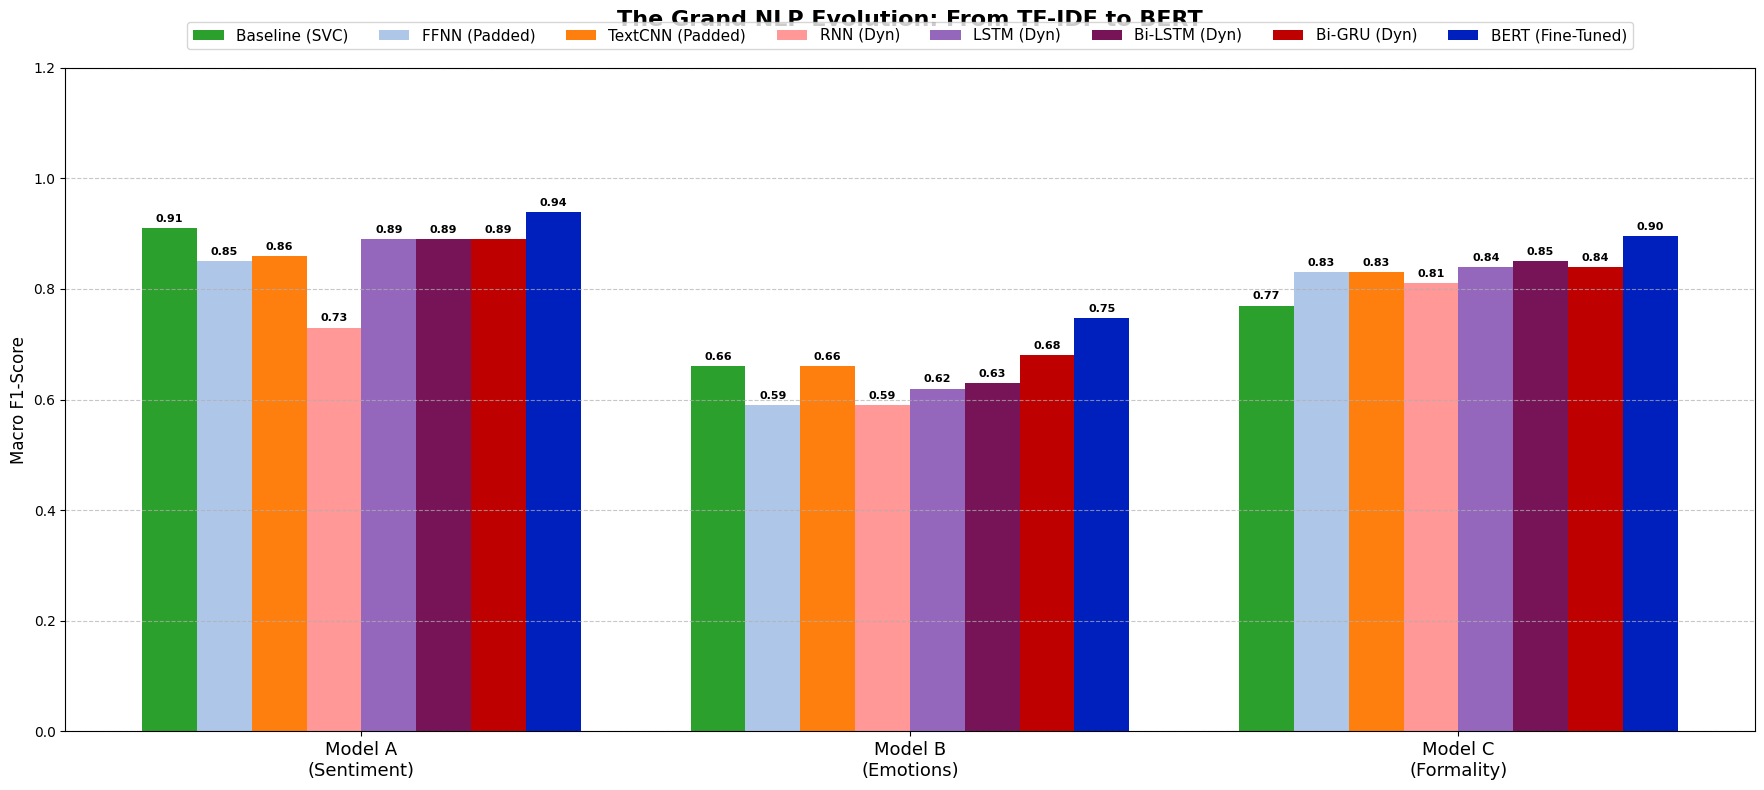

In [28]:
# Cell 44: The Ultimate Architectural Comparison (including BERT)
import matplotlib.pyplot as plt
import numpy as np

# Hardcoded metrics extracted from all previous logs
f1_svc        = [0.91, 0.66, 0.77] 
f1_ffnn       = [0.85, 0.59, 0.83] 
f1_cnn        = [0.86, 0.66, 0.83] 
f1_rnn_dyn    = [0.73, 0.59, 0.81] 
f1_lstm_dyn   = [0.89, 0.62, 0.84] 
f1_bilstm_dyn = [0.89, 0.63, 0.85] 
f1_bigru_dyn  = [0.89, 0.68, 0.84] # From Phase 5 (Cell 33)

# New metrics from Cell 43
f1_bert       = [f1_a_bert, f1_b_bert, f1_c_bert]

tasks = ['Model A\n(Sentiment)', 'Model B\n(Emotions)', 'Model C\n(Formality)']
x = np.arange(len(tasks))
width = 0.1  # Thinned down to fit 8 bars elegantly

fig, ax = plt.subplots(figsize=(18, 8))

# 8 bars comparing the complete evolution of our architectures
rects1 = ax.bar(x - 3.5*width, f1_svc, width, label='Baseline (SVC)', color='#2ca02c')
rects2 = ax.bar(x - 2.5*width, f1_ffnn, width, label='FFNN (Padded)', color='#aec7e8')
rects3 = ax.bar(x - 1.5*width, f1_cnn, width, label='TextCNN (Padded)', color='#ff7f0e')
rects4 = ax.bar(x - 0.5*width, f1_rnn_dyn, width, label='RNN (Dyn)', color='#ff9896')
rects5 = ax.bar(x + 0.5*width, f1_lstm_dyn, width, label='LSTM (Dyn)', color='#9467bd')
rects6 = ax.bar(x + 1.5*width, f1_bilstm_dyn, width, label='Bi-LSTM (Dyn)', color="#771458")
rects7 = ax.bar(x + 2.5*width, f1_bigru_dyn, width, label='Bi-GRU (Dyn)', color="#be0000")
rects8 = ax.bar(x + 3.5*width, f1_bert, width, label='BERT (Fine-Tuned)', color="#0020be")

# function to add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=8)

for r in [rects1, rects2, rects3, rects4, rects5, rects6, rects7, rects8]:
    autolabel(r)

ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title('The Grand NLP Evolution: From TF-IDF to BERT', fontsize=16, fontweight='bold', pad=30)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=13)
ax.set_ylim(0, 1.2) # Extended to give room for the massive legend
ax.grid(axis='y', linestyle='--', alpha=0.7)

# legend stretched across the top
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=8, fontsize=11)

plt.tight_layout()
plt.show()

Stage Conclusion: The Transformer Triumph and Computational Trade-offs

**1. Absolute Benchmark Records:** The fine-tuning of the BERT architecture shattered all previous performance ceilings. By leveraging multi-head self-attention and dynamic contextual embeddings, BERT established new all-time highs across every task: Model A (0.94), Model B (0.75), and Model C (0.90). 

**2. The Contextual Advantage (Models B & C):**
For multi-label emotions (Model B) and conversational formality (Model C), BERT proved to be unequivocally superior. It successfully unraveled the complex nuances, overlapping emotional states, and implicit context where recurrent sequence models (RNN/LSTM/GRU) previously struggled, delivering massive leaps in the Macro F1-score.

**3. The ROI Reality Check (Model A):**
Despite achieving the highest sentiment score (0.94), deploying BERT for Model A is computationally inefficient. Processing long-form IMDB reviews pushed our hardware to its thermal limits, requiring aggressive mitigation strategies (AMP, layer freezing, and truncating $L$ to 256). Given the minimal performance delta over the TF-IDF baseline (0.91) or Bi-GRU (0.89), the computational cost of $O(L^2)$ attention is disproportionate. For this specific data profile,SVM, TextCNN or Bi-GRU remains the optimal production choice regarding the accuracy-to-compute ratio.

## 6. Grand Conclusion: The Evolutionary Journey of NLP Architectures

This project provided a comprehensive, end-to-end historical and empirical evaluation of Natural Language Processing (NLP) paradigms, tracing the evolution of text representation and sequence modeling over the past decade. By benchmarking eight distinct architectures across three progressively complex tasks—**Model A (Sentiment Analysis)**, **Model B (Multi-Label Emotion Detection)**, and **Model C (Formality Classification)**—we exposed the mathematical boundaries, failure modes, and hardware constraints of each era.

### 1. The Paradigmatic Evolution Matrix

Our experimental roadmap highlights three fundamental architectural shifts in deep learning:

* **From Sparse Frequencies to Dynamic Context (TF-IDF vs. FastText vs. BERT):** Classical linear baselines (Linear SVC + TF-IDF) demonstrated remarkable resilience on smaller datasets but were structurally blind to word order. Migrating to dense static embeddings (FastText) introduced continuous semantic geometry but introduced the **"Mean Pooling Trap"**, where arithmetic averaging diluted token signatures into an ambiguous vector soup. BERT solved the polysemy dilemma by calculating dynamic, contextualized token representations at every layer using Query-Key-Value projections.
* **From Local Scanning to Recurrent Memory (TextCNN vs. RNN/LSTM/GRU):**
    `TextCNN` proved highly efficient at capturing local spatial $n$-gram signatures but was limited by its rigid kernel windows and lossy Max Pooling operations, which triggered a "context blindspot" in multi-layered narratives. While sequence-aware models (RNN family) natively process token topology step-by-step, vanilla implementations suffered complete gradient collapse (**"Padding Poisoning"**), requiring custom dynamic indexing. 
* **From Sequential Bottlenecks to Parallel Self-Attention (Bi-GRU vs. BERT):**
    Bidirectional models (`Bi-LSTM` and `Bi-GRU`) successfully resolved the recency bias of unidirectional networks, with `Bi-GRU` establishing our top classical benchmark (Macro F1 = 0.68 on multi-label emotions). However, their inherently sequential recurrent architecture prevents massive parallelization and restricts deep non-linear interaction across long token distances—boundaries shattered by BERT’s multi-head self-attention mechanisms.

### 2. Final Experimental Benchmark Summary

The empirical trajectory across our three target domains demonstrates clear architectural scaling laws:

| Architecture Family | Core Mechanism | Model A (Sentiment) | Model B (Emotions) | Model C (Formality) | Hardware & Efficiency Profile |
| :--- | :--- | :---: | :---: | :---: | :--- |
| **Linear Baseline** | TF-IDF + Sparse Linear SVC | 0.91 | 0.66 | 0.77 | Compute-light; highly linear; scales poorly to overlapping syntax. |
| **Averaging Network**| FastText + Static Mean Pooling | 0.85 | 0.59 | 0.83 | Destroys sequence structure; susceptible to semantic cancelation. |
| **Convolutional** | 1D Conv Filters + Max Pooling | 0.86 | 0.66 | 0.83 | Fast parallel execution; optimal for local word register scanning. |
| **Recurrent Sequence**| Dynamic Bi-LSTM / Bi-GRU | 0.89 | 0.68 | 0.84 | Preserves topological syntax; vulnerable to backward padding leakage. |
| **State-of-the-Art** | BERT Base Fine-Tuning + AMP | **0.94** | **0.75** | **0.90** | Highly nonlinear context tracking; quadratic complexity $O(L^2)$. |

### 3. Engineering Guidelines for Production Deployment

While fine-tuned Transformers established absolute records across all tasks, a rigorous MLOps deployment strategy demands balancing precision against compute constraints:

1.  **Model A (Long-Form Sentiment):** BERT achieved a peak Macro F1 of 0.94, but required aggressive computational compromises (Automatic Mixed Precision, sequence truncation to 256, and freezing 8 encoder layers) to prevent hardware thrashing on a 6GB mobile GPU. Given that `Linear SVC` (0.91) and `Bi-GRU` (0.89) perform within a narrow margin with a fraction of the inference latency, **Bi-GRU or a highly optimized TextCNN remains the most viable architecture** for low-latency production pipelines processing long text.
2.  **Model B (Multi-Label Emotions):** Deep semantic overlap and rare classes make this task highly non-linear. BERT’s massive leap to **0.75 F1** over the classical ceiling of 0.68 completely justifies its operational cost. **BERT is strictly mandatory** to capture cross-token emotional transitions.
3.  **Model C (Formality Style):** Formality mappings are strongly localized within sentence syntax. While BERT leads at 0.90, **Bi-LSTM/Bi-GRU models (0.84-0.85) offer a powerful, lightweight alternative** if serving infrastructure constraints restrict large-scale Transformer deployment.

Ultimately, this notebook demonstrates that while modern state-of-the-art models offer unparalleled context extraction capacities, mastering the foundational ML pipeline—from static vectors to dynamic neural graphs—is critical to building adaptable, resource-conscious, and scalable natural language solutions.

Archiving the Champion Models for Stage 7

To conduct a comprehensive Error Analysis and Threshold Tuning in our final notebook, we must serialize our selected "Champion Models". 

Based on our architectural evaluation:
* **Model B (Emotions) & Model C (Formality):** `BERT` is the undisputed champion. (Weights and Tokenizer already serialized).
* **Model A (Sentiment):** We select `Bi-GRU` as the primary champion due to its optimal balance of high accuracy (0.89 F1) and low computational latency, alongside the `Linear SVC` baseline for speed benchmarking.

To ensure strict reproducibility in the upcoming forensics pipeline, we will serialize the `Bi-GRU` PyTorch `state_dict` and, crucially, the custom `Vocabulary` object required to map string tokens to their exact integer indices.

In [37]:
# Cell 45: Bulletproof Exporting of the Bi-GRU Champion and Vocabulary
import os
import torch
import pickle

print("1. Preparing the Cookiecutter 'models/bigru/' directory...")
os.makedirs('models/bigru', exist_ok=True)
os.makedirs('models/vectorizers', exist_ok=True)

print("2. Checking memory state for Model A (Bi-GRU)...")
try:
    # Attempt to access the model. If it doesn't exist, this throws a NameError.
    _ = model_a_bigru 
    print("  -> SUCCESS: Model found in memory. Proceeding to serialization.")
except NameError:
    print("  -> WARNING: Model not found in memory (Kernel likely restarted).")
    print("  -> Executing emergency retraining pipeline...")
    
    # Re-initialize and train the model
    print("\n--- EMERGENCY RETRAINING: MODEL A (Sentiment, Bi-GRU) ---")
    model_a_bigru = TextBiGRU_Dynamic(embed_a, hidden_dim=128, output_dim=3, freeze_embeddings=True).to(device)
    model_a_bigru = train_model(
        model_a_bigru, loaders_a[0], loaders_a[1], 
        epochs=15, lr=0.001, is_multilabel=False, patience=3
    )
    print("\n--- EMERGENCY RETRAINING COMPLETE ---")

print("\n3. Serializing Model A (Bi-GRU) Weights...")
torch.save(model_a_bigru.state_dict(), 'models/bigru/model_a_bigru_sentiment.pth')
print("  -> Saved: models/bigru/model_a_bigru_sentiment.pth")

print("\n4. Serializing Custom Vocabulary for Model A...")
# loaders_a[3] contains our custom Vocabulary class instance for Model A
vocab_a = loaders_a[3] 
with open('models/vectorizers/vocab_a.pkl', 'wb') as f:
    pickle.dump(vocab_a, f)
print("  -> Saved Custom Dictionary to: models/vectorizers/vocab_a.pkl")

print("\nAll Champion Models and their tokenization rules are fully secured for Stage 7")

1. Preparing the Cookiecutter 'models/bigru/' directory...
2. Checking memory state for Model A (Bi-GRU)...
  -> WARNING: Model not found in memory (Kernel likely restarted).
  -> Executing emergency retraining pipeline...

--- EMERGENCY RETRAINING: MODEL A (Sentiment, Bi-GRU) ---


Epoch 1/15 | Train Loss: 0.4332 | Val Loss: 0.3206 | Val Macro F1: 0.8461


Epoch 2/15 | Train Loss: 0.2946 | Val Loss: 0.3085 | Val Macro F1: 0.8406


Epoch 3/15 | Train Loss: 0.2521 | Val Loss: 0.2837 | Val Macro F1: 0.8649


Epoch 4/15 | Train Loss: 0.2250 | Val Loss: 0.2583 | Val Macro F1: 0.8773


Epoch 5/15 | Train Loss: 0.2046 | Val Loss: 0.2538 | Val Macro F1: 0.8870


Epoch 6/15 | Train Loss: 0.1887 | Val Loss: 0.2564 | Val Macro F1: 0.8924


Epoch 7/15 | Train Loss: 0.1707 | Val Loss: 0.2670 | Val Macro F1: 0.8864


Epoch 8/15 | Train Loss: 0.1575 | Val Loss: 0.2634 | Val Macro F1: 0.8910


Epoch 9/15 | Train Loss: 0.1450 | Val Loss: 0.2824 | Val Macro F1: 0.8869
Early stopping triggered. Best Val F1: 0.8924

--- EMERGENCY RETRAINING COMPLETE ---

3. Serializing Model A (Bi-GRU) Weights...
  -> Saved: models/bigru/model_a_bigru_sentiment.pth

4. Serializing Custom Vocabulary for Model A...
  -> Saved Custom Dictionary to: models/vectorizers/vocab_a.pkl

All Champion Models and their tokenization rules are fully secured for Stage 7
